In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# ── Step 1: build scored_df from your ham10k__1_ CSVs ─────────────────────────
# Column names from ham10k__1_: prediction, confidence, fl_prediction, fl_confidence, label, group

def build_scored_df(erm_csv, fl_csv):
    erm = pd.read_csv(erm_csv)
    fl  = pd.read_csv(fl_csv)

    # ── Sanity check: confirm no duplicate image_ids before merge ──
    assert erm['image_id'].is_unique, "ERM CSV has duplicate image_ids"
    assert fl['image_id'].is_unique,  "FL CSV has duplicate image_ids"

    # ── Merge on image_id (safe regardless of row order) ──
    # Keep only the FL columns we need to avoid duplicate label/group cols
    fl_cols = ['image_id', 'fl_prediction', 'fl_confidence']
    if 'fl_logit_0' in fl.columns:
        fl_cols += ['fl_logit_0', 'fl_logit_1']

    df = erm.merge(fl[fl_cols], on='image_id', how='inner')

    # ── Alignment sanity check — print this before writing any numbers ──
    print("\n[sanity] head after merge:")
    print(df[['image_id', 'prediction', 'fl_prediction', 'label', 'group']].head(10).to_string())
    print(f"[sanity] rows ERM={len(erm):,}  FL={len(fl):,}  merged={len(df):,}")
    assert len(df) == len(erm), "Row count changed after merge — check for missing image_ids"

    # ── Scores ──
    eps = 1e-12
    p1 = df['confidence'].clip(eps, 1 - eps)
    p0 = 1 - p1

    df['score_disagreement']    = (df['confidence'] - df['fl_confidence']).abs()
    df['score_erm_entropy']     = -(p0 * np.log(p0) + p1 * np.log(p1))
    df['score_erm_uncertainty'] = 1 - df['confidence']

    df['erm_correct'] = (df['prediction'] == df['label']).astype(int)
    return df

# ── Step 2: eval harness ───────────────────────────────────────────────────────

def eval_abstention(df, score_col, thresholds, expected_groups=None):
    """
    Evaluate abstention across thresholds.

    Parameters
    ----------
    df              : DataFrame with columns: prediction, label, group, <score_col>
    score_col       : abstention score column — higher = more uncertain = abstain first
    thresholds      : list of float thresholds; samples with score > t are abstained
    expected_groups : list of group ids that must all be present for WGA to be valid.
                      If None, inferred from df. WGA is NaN if any group drops out.

    Returns
    -------
    DataFrame with one row per threshold.
    """
    if expected_groups is None:
        expected_groups = sorted(df['group'].unique())

    records = []
    for t in thresholds:
        retained  = df[df[score_col] <= t]
        abstained = df[df[score_col] >  t]
        coverage  = len(retained) / len(df)

        # WGA — only valid if all expected groups are still represented
        retained_groups = set(retained['group'].unique())
        if len(retained) == 0 or not set(expected_groups).issubset(retained_groups):
            wga = np.nan
            per_group_acc = {g: np.nan for g in expected_groups}
        else:
            per_group_acc = {}
            for g in expected_groups:
                g_mask = retained['group'] == g
                per_group_acc[g] = (retained.loc[g_mask, 'prediction'] == retained.loc[g_mask, 'label']).mean()
            wga = min(per_group_acc.values())

        avg_acc = (retained['prediction'] == retained['label']).mean() if len(retained) > 0 else np.nan

        # Per-group rejection rates
        per_group_rejection = {}
        for g in expected_groups:
            g_total    = (df['group'] == g).sum()
            g_abstained = (abstained['group'] == g).sum()
            per_group_rejection[g] = g_abstained / g_total if g_total > 0 else np.nan

        row = {
            'threshold' : t,
            'coverage'  : coverage,
            'wga'       : wga,
            'avg_acc'   : avg_acc,
        }
        for g in expected_groups:
            row[f'acc_group_{g}']    = per_group_acc.get(g, np.nan)
            row[f'reject_rate_g{g}'] = per_group_rejection.get(g, np.nan)

        records.append(row)

    return pd.DataFrame(records)


# ── Step 3: error|agreement + error|disagreement ──────────────────────────────

def disagreement_characterisation(df):
    agree    = df[df['prediction'] == df['fl_prediction']]
    disagree = df[df['prediction'] != df['fl_prediction']]

    print(f"Agreement   samples : {len(agree):,}  ({len(agree)/len(df):.1%})")
    print(f"Disagreement samples: {len(disagree):,}  ({len(disagree)/len(df):.1%})")
    print(f"Error | Agreement   : {(agree['prediction'] != agree['label']).mean():.4f}")
    print(f"Error | Disagreement: {(disagree['prediction'] != disagree['label']).mean():.4f}")

    print("\nPer-group disagreement rate:")
    for g in sorted(df['group'].unique()):
        g_df   = df[df['group'] == g]
        g_dis  = (g_df['prediction'] != g_df['fl_prediction']).mean()
        g_err  = (g_df['prediction'] != g_df['label']).mean()
        print(f"  Group {g}: disagree_rate={g_dis:.3f}  erm_error_rate={g_err:.3f}  n={len(g_df)}")


# ── Step 4: AUC-ROC comparison ────────────────────────────────────────────────

def auc_comparison(df, score_cols):
    errors = (df['prediction'] != df['label']).astype(int)
    print("\nAUC-ROC (predicting ERM errors):")
    for col in score_cols:
        auc = roc_auc_score(errors, df[col])
        print(f"  {col:30s}: {auc:.4f}")


# ── Step 5: run everything ────────────────────────────────────────────────────

def run_full_analysis(erm_csv, fl_csv, dataset_name, expected_groups=None):
    print(f"\n{'='*60}")
    print(f"  {dataset_name}")
    print(f"{'='*60}")

    df = build_scored_df(erm_csv, fl_csv)

    print(f"\nTotal test samples: {len(df):,}")
    print(f"ERM WGA: {df.groupby('group').apply(lambda x: (x['prediction']==x['label']).mean()).min():.4f}")

    # Disagreement characterisation
    print("\n--- Disagreement characterisation ---")
    disagreement_characterisation(df)

    # AUC-ROC
    score_cols = ['score_disagreement', 'score_erm_entropy', 'score_erm_uncertainty']
    auc_comparison(df, score_cols)

    # Abstention sweep
    thresholds = np.linspace(0, df['score_disagreement'].quantile(0.99), 20)
    print("\n--- Abstention sweep ---")

    all_results = {}
    for col in score_cols:
        t_max = df[col].quantile(0.99)
        thresholds_col = np.linspace(0, t_max, 20)
        res = eval_abstention(df, col, thresholds_col, expected_groups=expected_groups)
        all_results[col] = res

        # Best WGA at >= 50% coverage
        valid = res[(res['coverage'] >= 0.5) & res['wga'].notna()]
        if len(valid):
            best = valid.loc[valid['wga'].idxmax()]
            print(f"  {col:30s}: best WGA={best['wga']:.4f}  coverage={best['coverage']:.3f}  τ={best['threshold']:.4f}")

    # Per-group rejection rates at τ=0.1 for disagreement
    tau = 0.1
    abstained = df[df['score_disagreement'] > tau]
    print(f"\n--- Per-group rejection rates (disagreement, τ={tau}) ---")
    for g in sorted(df['group'].unique()):
        g_total     = (df['group'] == g).sum()
        g_abstained = (abstained['group'] == g).sum()
        print(f"  Group {g}: {g_abstained/g_total:.3f}  ({g_abstained}/{g_total})")

    return df, all_results


In [ ]:
wb_df, wb_results = run_full_analysis(
    erm_csv='/content/erm_test_predictions (1).csv',
    fl_csv='/content/free_lunch_test_predictions (1).csv',
    dataset_name='Waterbirds',
    expected_groups=[0,1,2,3]
)


  Waterbirds

[sanity] head after merge:
                                                            image_id  prediction  fl_prediction  label  group
0      001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg           1              1      1      3
1      001.Black_footed_Albatross/Black_Footed_Albatross_0002_55.jpg           1              1      1      2
2      001.Black_footed_Albatross/Black_Footed_Albatross_0085_92.jpg           1              1      1      3
3  001.Black_footed_Albatross/Black_Footed_Albatross_0025_796057.jpg           1              1      1      3
4  001.Black_footed_Albatross/Black_Footed_Albatross_0086_796062.jpg           1              1      1      2
5  001.Black_footed_Albatross/Black_Footed_Albatross_0049_796063.jpg           1              1      1      2
6  001.Black_footed_Albatross/Black_Footed_Albatross_0006_796065.jpg           1              1      1      2
7  001.Black_footed_Albatross/Black_Footed_Albatross_0016_796067.jpg          

/tmp/ipykernel_1124/3168507336.py:144: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(f"ERM WGA: {df.groupby('group').apply(lambda x: (x['prediction']==x['label']).mean()).min():.4f}")


  score_disagreement            : best WGA=0.8394  coverage=0.560  τ=0.0224
  score_erm_entropy             : best WGA=0.7671  coverage=0.715  τ=0.0363
  score_erm_uncertainty         : best WGA=0.7640  coverage=0.799  τ=0.0239

--- Per-group rejection rates (disagreement, τ=0.1) ---
  Group 0: 0.037  (83/2255)
  Group 1: 0.459  (1036/2255)
  Group 2: 0.344  (221/642)
  Group 3: 0.050  (32/642)


In [ ]:
celeba_df, celeba_results = run_full_analysis(
    erm_csv='/content/celeba_erm_test_predictions (1) (1).csv',
    fl_csv='/content/celeba_fl_test_predictions (1).csv',
    dataset_name='CelebA',
    expected_groups=[0,1,2,3]
)


  CelebA

[sanity] head after merge:
     image_id  prediction  fl_prediction  label  group
0  182638.jpg           0              0      0      0
1  182639.jpg           0              0      0      0
2  182640.jpg           0              1      0      0
3  182641.jpg           0              0      0      0
4  182642.jpg           0              0      0      0
5  182643.jpg           0              0      0      1
6  182644.jpg           0              0      0      1
7  182645.jpg           0              0      0      0
8  182646.jpg           0              0      0      0
9  182647.jpg           0              0      0      1
[sanity] rows ERM=19,962  FL=19,962  merged=19,962

Total test samples: 19,962
ERM WGA: 0.5833

--- Disagreement characterisation ---
Agreement   samples : 18,594  (93.1%)
Disagreement samples: 1,368  (6.9%)
Error | Agreement   : 0.0333
Error | Disagreement: 0.2961

Per-group disagreement rate:
  Group 0: disagree_rate=0.080  erm_error_rate=0.048  n=9767


/tmp/ipykernel_1124/3168507336.py:144: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(f"ERM WGA: {df.groupby('group').apply(lambda x: (x['prediction']==x['label']).mean()).min():.4f}")


  score_disagreement            : best WGA=0.6724  coverage=0.760  τ=0.0234
  score_erm_entropy             : best WGA=0.6162  coverage=0.905  τ=0.1425
  score_erm_uncertainty         : best WGA=0.6000  coverage=0.961  τ=0.1941

--- Per-group rejection rates (disagreement, τ=0.1) ---
  Group 0: 0.149  (1455/9767)
  Group 1: 0.078  (590/7535)
  Group 2: 0.223  (553/2480)
  Group 3: 0.383  (69/180)


In [ ]:
g3 = celeba_df[celeba_df['group'] == 3]
g3_acc_before = (g3['prediction'] == g3['label']).mean()
print("Group 3 accuracy BEFORE:", g3_acc_before)

Group 3 accuracy BEFORE: 0.5833333333333334


In [ ]:
tau = 0.1
retained = celeba_df[celeba_df['score_disagreement'] <= tau]
g3_after = retained[retained['group'] == 3]

g3_acc_after = (g3_after['prediction'] == g3_after['label']).mean()
coverage = len(retained) / len(celeba_df)

print("Group 3 accuracy AFTER:", g3_acc_after)
print("Coverage:", coverage)

Group 3 accuracy AFTER: 0.6126126126126126
Coverage: 0.8663961526901112


In [ ]:
tau = 0.1
abstained = celeba_df[celeba_df['score_disagreement'] > tau]

for g in sorted(celeba_df['group'].unique()):
    g_total = (celeba_df['group'] == g).sum()
    g_abs   = (abstained['group'] == g).sum()
    print(f"Group {g}: {g_abs/g_total:.3f}")

Group 0: 0.149
Group 1: 0.078
Group 2: 0.223
Group 3: 0.383


In [ ]:
best_tau = celeba_results['score_disagreement'].loc[
    celeba_results['score_disagreement']['wga'].idxmax()
]['threshold']

In [ ]:
tau=best_tau
retained = celeba_df[celeba_df['score_disagreement'] <= tau]
g3_after = retained[retained['group'] == 3]

g3_acc_after = (g3_after['prediction'] == g3_after['label']).mean()
coverage = len(retained) / len(celeba_df)

print("Group 3 accuracy AFTER:", g3_acc_after)
print("Coverage:", coverage)

Group 3 accuracy AFTER: 0.6724137931034483
Coverage: 0.7595431319507063


In [ ]:
best_tau

np.float64(0.023364063720954082)

In [ ]:
!cd "/content/drive/MyDrive/TDL/Final models and inference"

In [ ]:
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (648 kB/s)
Selecting previously unselected package tree.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tree "/content/drive/MyDrive/TDL/Final models and inference"

/content/drive/MyDrive/TDL/Final models and inference
├── CelebA
│   ├── celeba_erm_best.pth
│   ├── celeba_erm_final.pth
│   ├── celeba_erm_test_predictions (1).csv
│   ├── celeba_fl_backbone.pth
│   ├── celeba_fl_final.pth
│   ├── celeba_fl_test_predictions.csv
│   ├── celeba.ipynb
│   ├── celeba_metadata.csv
│   └── Day 3
│       ├── celeba_group_analysis.csv
│       └── celeba_group_disagreement_analysis.py
├── combined
│   ├── auc_error_prediction_analysis.py
│   ├── auc_error_prediction.csv
│   ├── Day 3
│   │   ├── build_final_results_table.py
│   │   └── final_results_table.csv
│   ├── Day 4
│   │   ├── celeba_sweep_results.csv
│   │   ├── figure1_wga_vs_coverage.pdf
│   │   ├── figure1_wga_vs_coverage.png
│   │   ├── figure2_group_scatter.pdf
│   │   ├── generate_sweep_results.py
│   │   ├── plot_group_disagreement_vs_error.py
│   │   └── sweep_results.csv
│   ├── error_agreement_disagreement_analysis.py
│   └── error_disagreement_comparison.csv
├── HAM
│   ├── abstention_summ

In [ ]:
!ls

celeba	eval.py  ham  waterbirds


In [ ]:
%cd "/content/drive/MyDrive/TDL/final_clean"

/content/drive/MyDrive/TDL/final_clean


In [ ]:
!python eval.py


===== Waterbirds =====
/content/drive/MyDrive/TDL/final_clean/eval.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("group").apply(
ERM WGA: 0.6838006230529595

AUC:
{'disagreement': np.float64(0.7441495945619006), 'entropy': np.float64(0.862152138793285), 'confidence': np.float64(0.862152138793285)}
/content/drive/MyDrive/TDL/final_clean/eval.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this

In [ ]:
!python eval.py


===== Waterbirds =====
ERM WGA: 0.6838006230529595

AUC:
{'disagreement': np.float64(0.7441495945619006), 'entropy': np.float64(0.862152138793285), 'confidence': np.float64(0.862152138793285)}
score_disagreement: best WGA=0.8394, coverage=0.560
score_entropy: best WGA=0.7700, coverage=0.683
score_confidence: best WGA=0.7607, coverage=0.794

Selected tau for analysis: 0.0224

Rejection rates at tau=0.022377278334216058
Group 0: 0.123
Group 1: 0.768
Group 2: 0.681
Group 3: 0.159

Per-group accuracy BEFORE vs AFTER (tau=0.022377278334216058)
Group 0: 0.996 → 0.999
Group 1: 0.829 → 0.839
Group 2: 0.684 → 0.854
Group 3: 0.964 → 0.994

Error | Agreement: 0.0962756052141527
Error | Disagreement: 0.24056603773584906
Total agreed: 5370
Total disagreed: 424

Minority disagreement rate: 0.12646559048428208
Majority disagreement rate: 0.011557563324146411

===== CelebA =====
ERM WGA: 0.5833333333333334

AUC:
{'disagreement': np.float64(0.8559733777656036), 'entropy': np.float64(0.9233589490624009

In [ ]:
"""
aggregate_results.py
--------------------
Run this script from the folder containing all your prediction CSVs.
It aggregates all metrics across 3 seeds and prints every fill-in value
for the paper's Results section (Tables 1–4 + Figure 4 inline numbers).

Figures 1–4 are generated by running eval.py directly (see bottom of this file).

Usage:
    python aggregate_results.py
"""

import warnings
import numpy as np
import pandas as pd
import sys, os

warnings.filterwarnings("ignore")

# ── Import from your eval script (must be in same directory) ────────────
sys.path.insert(0, ".")
from eval import (
    load_and_merge, add_scores, compute_wga, compute_auc,
    eval_abstention, select_best_tau, _compute_figure4_metrics, compute_error_by_score,
    compute_error_by_score, compute_group_error_by_score, compute_group_rejection
)

# ════════════════════════════════════════════════════════════════════════
#  EDIT THIS BLOCK — match your actual CSV filenames for each seed
# ════════════════════════════════════════════════════════════════════════
SEEDS = {
    "Waterbirds": {
        # ERM seed 1 paired with 3 different FL heads
        "erm_fl": [
            ("/path/to/erm_seed1.csv", "/path/to/fl_seed1.csv"),
            ("/path/to/erm_seed1.csv", "/path/to/fl_seed2.csv"),
            ("/path/to/erm_seed1.csv", "/path/to/fl_seed3.csv"),
        ],
        # ERM seed 1 vs ERM seed 2 (single comparison)
        "erm_erm": (
            "/path/to/erm_seed1.csv",
            "/path/to/erm_seed2.csv"
        ),
    },
    "CelebA": {
        "erm_fl": [
            ("/path/to/celeba_erm_seed1.csv", "/path/to/celeba_fl_seed1.csv"),
            ("/path/to/celeba_erm_seed1.csv", "/path/to/celeba_fl_seed2.csv"),
            ("/path/to/celeba_erm_seed1.csv", "/path/to/celeba_fl_seed3.csv"),
        ],
        "erm_erm": (
            "/path/to/celeba_erm_seed1.csv",
            "/path/to/celeba_erm_seed2.csv"
        ),
    },
    "HAM10000": {
        "erm_fl": [
            ("/path/to/ham_erm_seed1.csv", "/path/to/ham_fl_seed1.csv"),
            ("/path/to/ham_erm_seed1.csv", "/path/to/ham_fl_seed2.csv"),
            ("/path/to/ham_erm_seed1.csv", "/path/to/ham_fl_seed3.csv"),
        ],
        "erm_erm": (
            "/path/to/ham_erm_seed1.csv",
            "/path/to/ham_erm_seed2.csv"
        ),
    },
}
# ════════════════════════════════════════════════════════════════════════

SCORE_COLS   = ["score_disagreement", "score_entropy", "score_confidence"]
METHOD_NAMES = ["Disagreement",       "Entropy",       "Confidence"]

def ms(vals):
    """Return 'mean ± std' string from a list, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    if not v:
        return "N/A"
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}"

def mean_only(vals):
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan

# ── Collect per-dataset results ──────────────────────────────────────────
all_results = {}

for dataset, seed_files in SEEDS.items():
    buckets = {
        "erm_wga":          [],
        # Table 1 — best WGA at best threshold per method
        "best_wga_dis":     [],
        "best_wga_ent":     [],
        "best_wga_conf":    [],
        # Table 1 — coverage at best WGA threshold per method
        "best_cov_dis":     [],
        "best_cov_ent":     [],
        "best_cov_conf":    [],
        # Table 2 — AUC (error detection)
        "auc_dis":          [],
        "auc_ent":          [],
        "auc_conf":         [],
        # Table 3 — selected tau (coverage >= 0.5) + its WGA and coverage
        "sel_tau":          [],
        "sel_tau_wga":      [],
        "sel_tau_cov":      [],
        # Table 4 / Figure 4 — error on agreement vs disagreement
        "err_on_agree":     [],
        "err_on_disagree":  [],
        "err_ratio":        [],
        # NEW — entropy error split
        "err_low_ent": [],
        "err_high_ent": [],
        "ratio_ent": [],

        # NEW — confidence error split
        "err_low_conf": [],
        "err_high_conf": [],
        "ratio_conf": [],

        # NEW — group-level analysis
        "group_err_dis": [],
        "group_err_ent": [],
        "group_rej_dis": [],
        "group_rej_ent": [],
    }

    for erm_csv, fl_csv in seed_files:
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP] Missing files for {dataset}: {erm_csv} or {fl_csv}")
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        # --- ERM WGA baseline ---
        buckets["erm_wga"].append(compute_wga(df))

        # --- AUC scores ---
        aucs = compute_auc(df)
        buckets["auc_dis"].append(aucs["disagreement"])
        buckets["auc_ent"].append(aucs["entropy"])
        buckets["auc_conf"].append(aucs["confidence"])

        # --- Best WGA / coverage per method ---
        thr = np.linspace(0, min(0.5, float(df["score_disagreement"].quantile(0.99))), 20)
        for sc, bwga_key, bcov_key in [
            ("score_disagreement", "best_wga_dis", "best_cov_dis"),
            ("score_entropy",      "best_wga_ent", "best_cov_ent"),
            ("score_confidence",   "best_wga_conf","best_cov_conf"),
        ]:
            res   = eval_abstention(df, sc, thr)
            valid = res.dropna(subset=["wga"])
            if valid.empty:
                buckets[bwga_key].append(np.nan)
                buckets[bcov_key].append(np.nan)
            else:
                best = valid.loc[valid["wga"].idxmax()]
                buckets[bwga_key].append(float(best["wga"]))
                buckets[bcov_key].append(float(best["coverage"]))

        # --- Selected tau (coverage >= 0.5) ---
        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau      = select_best_tau(res_dis, min_coverage=0.5)
            tau_row  = res_dis[np.isclose(res_dis["threshold"], tau)].iloc[0]
            buckets["sel_tau"].append(tau)
            buckets["sel_tau_wga"].append(float(tau_row["wga"]))
            buckets["sel_tau_cov"].append(float(tau_row["coverage"]))
        except ValueError:
            buckets["sel_tau"].append(np.nan)
            buckets["sel_tau_wga"].append(np.nan)
            buckets["sel_tau_cov"].append(np.nan)

        # --- Figure 4 metrics ---
        fig4 = _compute_figure4_metrics(erm_csv, fl_csv)
        buckets["err_on_agree"].append(fig4["error_on_agreement"])
        buckets["err_on_disagree"].append(fig4["error_on_disagreement"])
        buckets["err_ratio"].append(fig4["ratio"])

        # --- NEW: entropy & confidence error concentration ---

        # entropy tau
        res_ent = eval_abstention(df, "score_entropy", thr)
        try:
            tau_ent = select_best_tau(res_ent, min_coverage=0.5)
            ent_metrics = compute_error_by_score(df, "score_entropy", tau_ent)

            buckets["err_low_ent"].append(ent_metrics["error_low"])
            buckets["err_high_ent"].append(ent_metrics["error_high"])
            buckets["ratio_ent"].append(ent_metrics["ratio"])
        except:
            buckets["err_low_ent"].append(np.nan)
            buckets["err_high_ent"].append(np.nan)
            buckets["ratio_ent"].append(np.nan)


        # confidence tau
        res_conf = eval_abstention(df, "score_confidence", thr)
        try:
            tau_conf = select_best_tau(res_conf, min_coverage=0.5)
            conf_metrics = compute_error_by_score(df, "score_confidence", tau_conf)

            buckets["err_low_conf"].append(conf_metrics["error_low"])
            buckets["err_high_conf"].append(conf_metrics["error_high"])
            buckets["ratio_conf"].append(conf_metrics["ratio"])
        except:
            buckets["err_low_conf"].append(np.nan)
            buckets["err_high_conf"].append(np.nan)
            buckets["ratio_conf"].append(np.nan)

        # --- NEW: GROUP-WISE ANALYSIS ---

        # disagreement tau (already computed earlier ideally, else recompute)
        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau_dis = select_best_tau(res_dis, min_coverage=0.5)

            group_err_dis = compute_group_error_by_score(df, "score_disagreement", tau_dis)
            group_rej_dis = compute_group_rejection(df, "score_disagreement", tau_dis)

            buckets["group_err_dis"].append(group_err_dis)
            buckets["group_rej_dis"].append(group_rej_dis)
        except:
            buckets["group_err_dis"].append(None)
            buckets["group_rej_dis"].append(None)


        # entropy tau
        res_ent = eval_abstention(df, "score_entropy", thr)
        try:
            tau_ent = select_best_tau(res_ent, min_coverage=0.5)

            group_err_ent = compute_group_error_by_score(df, "score_entropy", tau_ent)
            group_rej_ent = compute_group_rejection(df, "score_entropy", tau_ent)

            buckets["group_err_ent"].append(group_err_ent)
            buckets["group_rej_ent"].append(group_rej_ent)
        except:
            buckets["group_err_ent"].append(None)
            buckets["group_rej_ent"].append(None)

    all_results[dataset] = buckets


# ════════════════════════════════════════════════════════════════════════
#  PRINT ALL FILL-IN VALUES
# ════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())

print("\n" + "═"*68)
print("  TABLE 1 — Worst-Group Accuracy (best threshold, coverage ≥ 50%)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'ERM WGA':>16} {'Disagreement':>16} {'Entropy':>16} {'Confidence':>16}"
print(header)
print("-"*68)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['erm_wga']):>16} {ms(b['best_wga_dis']):>16} "
          f"{ms(b['best_wga_ent']):>16} {ms(b['best_wga_conf']):>16}")


print("\n" + "═"*68)
print("  TABLE 2 — Error-Detection AUC (AUROC, predicting ERM errors)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Disagreement':>16} {'Entropy':>16} {'Confidence':>16}"
print(header)
print("-"*52)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['auc_dis']):>16} {ms(b['auc_ent']):>16} {ms(b['auc_conf']):>16}")


print("\n" + "═"*68)
print("  TABLE 3 — Selected Disagreement τ (coverage ≥ 0.50)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Best τ':>14} {'WGA @ τ':>16} {'Coverage @ τ':>16}"
print(header)
print("-"*60)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['sel_tau']):>14} {ms(b['sel_tau_wga']):>16} {ms(b['sel_tau_cov']):>16}")


print("\n" + "═"*68)
print("  TABLE 4 — Figure 4 Numbers: Error Rate on Agreement vs Disagreement")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Err|Agree':>14} {'Err|Disagree':>16} {'Ratio (×)':>12}"
print(header)
print("-"*56)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['err_on_agree']):>14} {ms(b['err_on_disagree']):>16} {ms(b['err_ratio']):>12}")

print("\n" + "═"*75)
print("  TABLE 5 — Error Concentration: Entropy vs Confidence")
print("  Format: mean ± std over 3 seeds")
print("═"*75)

header = f"{'Dataset':<12} {'Method':<12} {'Err|Low':>12} {'Err|High':>14} {'Ratio (×)':>12}"
print(header)
print("-"*75)

for d in DATASETS:
    b = all_results[d]

    # Entropy
    print(f"{d:<12} {'Entropy':<12} "
          f"{ms(b['err_low_ent']):>12} "
          f"{ms(b['err_high_ent']):>14} "
          f"{ms(b['ratio_ent']):>12}")

    # Confidence
    print(f"{d:<12} {'Confidence':<12} "
          f"{ms(b['err_low_conf']):>12} "
          f"{ms(b['err_high_conf']):>14} "
          f"{ms(b['ratio_conf']):>12}")


print("\n" + "═"*75)
print("  TABLE 6 — Group-wise Rejection Rates (Disagreement vs Entropy)")
print("═"*75)

for d in DATASETS:
    print(f"\nDataset: {d}")

    b = all_results[d]

    # take first seed (they'll be similar anyway)
    dis = b["group_rej_dis"][0]
    ent = b["group_rej_ent"][0]

    if dis is None or ent is None:
        print("  Skipped (missing data)")
        continue

    merged = dis.merge(ent, on="group", suffixes=("_dis", "_ent"))

    for _, row in merged.iterrows():
        print(f"  Group {int(row['group'])}: "
              f"Dis={row['rejection_rate_dis']:.3f}, "
              f"Ent={row['rejection_rate_ent']:.3f}")


print("\n" + "═"*68)
print("  COVERAGE AT BEST WGA — for Figure 1 axis / inline text")
print("═"*68)
header = f"{'Dataset':<12} {'Dis coverage':>16} {'Ent coverage':>16} {'Conf coverage':>16}"
print(header)
print("-"*62)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['best_cov_dis']):>16} {ms(b['best_cov_ent']):>16} {ms(b['best_cov_conf']):>16}")


print("\n" + "═"*68)
print("  DELTA — WGA improvement of Disagreement over ERM baseline")
print("═"*68)
for d in DATASETS:
    b = all_results[d]
    erm   = mean_only(b["erm_wga"])
    best  = mean_only(b["best_wga_dis"])
    delta = best - erm if not (np.isnan(erm) or np.isnan(best)) else np.nan
    print(f"  {d}: ERM={erm:.4f}  →  Disagreement best WGA={best:.4f}  "
          f"  Δ = {delta:+.4f} ({delta*100:+.1f} pp)")


print("""
════════════════════════════════════════════════════════════════════════
  FIGURE GENERATION — run these commands in your CSV directory:
════════════════════════════════════════════════════════════════════════

  Figures 1–4 are generated by running eval.py directly.
  Each figure function reads from the SINGLE-SEED CSVs defined in
  DATASETS at the top of eval.py. Point those paths to whichever seed
  you want displayed (typically seed 0 or the median seed).

  Figure 1 — WGA vs Coverage (3 methods × 3 datasets)
    Requires: sweep_results.csv, celeba_sweep_results.csv,
              final_results_table.csv  (columns: dataset, erm_wga)
    Command:  python eval__2_.py   [calls generate_figure1()]
    Output:   figure1_wga_vs_coverage.pdf / .png

  Figure 2 — Group-level disagreement rate vs ERM error rate (scatter)
    Requires: per-dataset ERM + FL CSVs set in DATASETS dict in eval.py
    Command:  python eval__2_.py   [calls generate_figure2()]
    Output:   figure2_group_scatter.pdf

  Figure 3 — Per-group rejection rate bar chart (disagreement at best τ)
    Requires: same CSVs as Figure 2
              CelebA also needs celeba_sweep_results.csv for τ selection
    Command:  python eval__2_.py   [calls generate_figure3()]
    Output:   figure3_rejection_rates.pdf

  Figure 4 — Error rate on agreement vs disagreement (grouped bars + ratio)
    Requires: same CSVs as Figure 2
    Command:  python eval__2_.py   [calls generate_figure4()]
    Output:   figure4_error_disagreement.pdf
    Numbers:  printed by TABLE 4 above

════════════════════════════════════════════════════════════════════════
  final_results_table.csv  — needed by Figure 1
  Create it from TABLE 1 above:

    dataset,erm_wga
    Waterbirds,[A1 mean value]
    CelebA,[A2 mean value]
    HAM10000,[A3 mean value]
════════════════════════════════════════════════════════════════════════
""")


════════════════════════════════════════════════════════════════════
  TABLE 1 — Worst-Group Accuracy (best threshold, coverage ≥ 50%)
  Format: mean ± std over 3 seeds
════════════════════════════════════════════════════════════════════
Dataset               ERM WGA     Disagreement          Entropy       Confidence
--------------------------------------------------------------------
Waterbirds    0.6838 ± 0.0000  0.8258 ± 0.0096  0.7691 ± 0.0007  0.7605 ± 0.0003
CelebA        0.5833 ± 0.0000  0.6670 ± 0.0043  0.6162 ± 0.0000  0.6042 ± 0.0000
HAM10000      0.6587 ± 0.0000  0.7609 ± 0.0157  0.8286 ± 0.0000  0.7297 ± 0.0000

════════════════════════════════════════════════════════════════════
  TABLE 2 — Error-Detection AUC (AUROC, predicting ERM errors)
  Format: mean ± std over 3 seeds
════════════════════════════════════════════════════════════════════
Dataset          Disagreement          Entropy       Confidence
----------------------------------------------------
Waterbirds    0

In [ ]:
"""
aggregate_results.py
--------------------
Run this script from the folder containing all your prediction CSVs.
It aggregates all metrics across 3 seeds and prints every fill-in value
for the paper's Results section (Tables 1–4 + Figure 4 inline numbers).

Figures 1–4 are generated by running eval.py directly (see bottom of this file).

Usage:
    python aggregate_results.py
"""

import warnings
import numpy as np
import pandas as pd
import sys, os

warnings.filterwarnings("ignore")

# ── Import from your eval script (must be in same directory) ────────────
sys.path.insert(0, ".")
from eval import (
    load_and_merge, load_and_merge_erm_erm, add_scores, compute_wga, compute_auc,
    eval_abstention, select_best_tau, _compute_figure4_metrics, compute_error_by_score,
    compute_group_error_by_score, compute_group_rejection
)

# ════════════════════════════════════════════════════════════════════════
#  EDIT THIS BLOCK — match your actual CSV filenames for each seed
# ════════════════════════════════════════════════════════════════════════
SEEDS = {
    "Waterbirds": {
        # ERM-FL: Same ERM backbone with 3 different FL heads
        "erm_fl": [
            ("/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
             "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
             "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_123.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
             "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_456.csv"),
        ],
        # ERM-ERM: Two different ERM backbones (single comparison)
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
            "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv"
        ),
    },
    "CelebA": {
        "erm_fl": [
            ("/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_123.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_456.csv"),
        ],
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
            "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv"
        ),
    },
    "HAM10000": {
        "erm_fl": [
            ("/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_seed123.csv"),
            ("/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
             "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_456.csv"),
        ],
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
            "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv"
        ),
    },
}
# ════════════════════════════════════════════════════════════════════════

SCORE_COLS   = ["score_disagreement", "score_entropy", "score_confidence"]
METHOD_NAMES = ["Disagreement",       "Entropy",       "Confidence"]

def ms(vals):
    """Return 'mean ± std' string from a list, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    if not v:
        return "N/A"
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}"

def mean_only(vals):
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan


# ── Collect per-dataset results ──────────────────────────────────────────
all_results = {}

for dataset in SEEDS.keys():
    buckets = {
        "erm_wga":          [],

        # Table 1 — best WGA at best threshold per method (ERM-FL pairs)
        "best_wga_dis":     [],
        "best_wga_ent":     [],
        "best_wga_conf":    [],

        # Table 1 — coverage at best WGA threshold per method
        "best_cov_dis":     [],
        "best_cov_ent":     [],
        "best_cov_conf":    [],

        # Table 2 — AUC (error detection) for ERM-FL
        "auc_dis":          [],
        "auc_ent":          [],
        "auc_conf":         [],

        # Table 3 — selected tau (coverage >= 0.5) + its WGA and coverage
        "sel_tau":          [],
        "sel_tau_wga":      [],
        "sel_tau_cov":      [],

        # Table 4 / Figure 4 — error on agreement vs disagreement
        "err_on_agree":     [],
        "err_on_disagree":  [],
        "err_ratio":        [],

        # Table 5 — entropy error split
        "err_low_ent": [],
        "err_high_ent": [],
        "ratio_ent": [],

        # Table 5 — confidence error split
        "err_low_conf": [],
        "err_high_conf": [],
        "ratio_conf": [],

        # Table 6 — group-level analysis (ERM-FL)
        "group_err_dis": [],
        "group_err_ent": [],
        "group_rej_dis": [],
        "group_rej_ent": [],

        # NEW: ERM-ERM ablation metrics (single values, not lists)
        "best_wga_dis_erm_erm": None,
        "auc_dis_erm_erm": None,
        "group_rej_dis_erm_erm": None,
    }

    # ═══════════════════════════════════════════════════════════════════
    # Process ERM-FL pairs (3 seeds)
    # ═══════════════════════════════════════════════════════════════════
    for erm_csv, fl_csv in SEEDS[dataset]["erm_fl"]:
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP] Missing files for {dataset}: {erm_csv} or {fl_csv}")
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        # --- ERM WGA baseline (only compute once) ---
        if len(buckets["erm_wga"]) == 0:
            buckets["erm_wga"].append(compute_wga(df))

        # --- AUC scores ---
        aucs = compute_auc(df)
        buckets["auc_dis"].append(aucs["disagreement"])
        buckets["auc_ent"].append(aucs["entropy"])
        buckets["auc_conf"].append(aucs["confidence"])

        # --- Best WGA / coverage per method ---
        thr = np.linspace(0, min(0.5, float(df["score_disagreement"].quantile(0.99))), 20)
        for sc, bwga_key, bcov_key in [
            ("score_disagreement", "best_wga_dis", "best_cov_dis"),
            ("score_entropy",      "best_wga_ent", "best_cov_ent"),
            ("score_confidence",   "best_wga_conf","best_cov_conf"),
        ]:
            res   = eval_abstention(df, sc, thr)
            valid = res.dropna(subset=["wga"])
            if valid.empty:
                buckets[bwga_key].append(np.nan)
                buckets[bcov_key].append(np.nan)
            else:
                best = valid.loc[valid["wga"].idxmax()]
                buckets[bwga_key].append(float(best["wga"]))
                buckets[bcov_key].append(float(best["coverage"]))


        # --- Selected tau (coverage >= 0.5) ---
        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau      = select_best_tau(res_dis, min_coverage=0.5)
            tau_row  = res_dis[np.isclose(res_dis["threshold"], tau)].iloc[0]
            buckets["sel_tau"].append(tau)
            buckets["sel_tau_wga"].append(float(tau_row["wga"]))
            buckets["sel_tau_cov"].append(float(tau_row["coverage"]))
        except ValueError:
            buckets["sel_tau"].append(np.nan)
            buckets["sel_tau_wga"].append(np.nan)
            buckets["sel_tau_cov"].append(np.nan)

        # --- Figure 4 metrics ---
        fig4 = _compute_figure4_metrics(erm_csv, fl_csv)
        buckets["err_on_agree"].append(fig4["error_on_agreement"])
        buckets["err_on_disagree"].append(fig4["error_on_disagreement"])
        buckets["err_ratio"].append(fig4["ratio"])

        # --- Entropy & confidence error concentration ---
        res_ent = eval_abstention(df, "score_entropy", thr)
        try:
            tau_ent = select_best_tau(res_ent, min_coverage=0.5)
            ent_metrics = compute_error_by_score(df, "score_entropy", tau_ent)
            buckets["err_low_ent"].append(ent_metrics["error_low"])
            buckets["err_high_ent"].append(ent_metrics["error_high"])
            buckets["ratio_ent"].append(ent_metrics["ratio"])
        except:
            buckets["err_low_ent"].append(np.nan)
            buckets["err_high_ent"].append(np.nan)
            buckets["ratio_ent"].append(np.nan)

        res_conf = eval_abstention(df, "score_confidence", thr)
        try:
            tau_conf = select_best_tau(res_conf, min_coverage=0.5)
            conf_metrics = compute_error_by_score(df, "score_confidence", tau_conf)
            buckets["err_low_conf"].append(conf_metrics["error_low"])
            buckets["err_high_conf"].append(conf_metrics["error_high"])
            buckets["ratio_conf"].append(conf_metrics["ratio"])
        except:
            buckets["err_low_conf"].append(np.nan)
            buckets["err_high_conf"].append(np.nan)
            buckets["ratio_conf"].append(np.nan)

        # --- Group-wise analysis ---
        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau_dis = select_best_tau(res_dis, min_coverage=0.5)
            group_err_dis = compute_group_error_by_score(df, "score_disagreement", tau_dis)
            group_rej_dis = compute_group_rejection(df, "score_disagreement", tau_dis)
            buckets["group_err_dis"].append(group_err_dis)
            buckets["group_rej_dis"].append(group_rej_dis)
        except:
            buckets["group_err_dis"].append(None)
            buckets["group_rej_dis"].append(None)

        res_ent = eval_abstention(df, "score_entropy", thr)
        try:
            tau_ent = select_best_tau(res_ent, min_coverage=0.5)
            group_err_ent = compute_group_error_by_score(df, "score_entropy", tau_ent)
            group_rej_ent = compute_group_rejection(df, "score_entropy", tau_ent)
            buckets["group_err_ent"].append(group_err_ent)
            buckets["group_rej_ent"].append(group_rej_ent)
        except:
            buckets["group_err_ent"].append(None)
            buckets["group_rej_ent"].append(None)

    # ═══════════════════════════════════════════════════════════════════
    # Process ERM-ERM pair (single comparison)
    # ═══════════════════════════════════════════════════════════════════
    erm1_csv, erm2_csv = SEEDS[dataset]["erm_erm"]
    if os.path.exists(erm1_csv) and os.path.exists(erm2_csv):
        print(f"  [INFO] Processing ERM-ERM for {dataset}")
        df_erm = add_scores(load_and_merge_erm_erm(erm1_csv, erm2_csv))

        # AUC for ERM-ERM disagreement
        aucs_erm = compute_auc(df_erm)
        buckets["auc_dis_erm_erm"] = aucs_erm["disagreement"]

        # Best WGA for ERM-ERM
        thr = np.linspace(0, min(0.5, float(df_erm["score_disagreement"].quantile(0.99))), 20)
        res_dis_erm = eval_abstention(df_erm, "score_disagreement", thr)
        valid = res_dis_erm.dropna(subset=["wga"])
        if not valid.empty:
            best = valid.loc[valid["wga"].idxmax()]
            buckets["best_wga_dis_erm_erm"] = float(best["wga"])

        # Group rejection for ERM-ERM
        try:
            tau_dis_erm = select_best_tau(res_dis_erm, min_coverage=0.5)
            group_rej_erm = compute_group_rejection(df_erm, "score_disagreement", tau_dis_erm)
            buckets["group_rej_dis_erm_erm"] = group_rej_erm
        except:
            buckets["group_rej_dis_erm_erm"] = None
    else:
        print(f"  [SKIP] Missing ERM-ERM files for {dataset}")

    all_results[dataset] = buckets


# ════════════════════════════════════════════════════════════════════════
#  PRINT ALL FILL-IN VALUES (EXISTING TABLES - UNCHANGED)
# ════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())

print("\n" + "═"*68)
print("  TABLE 1 — Worst-Group Accuracy (best threshold, coverage ≥ 50%)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'ERM WGA':>16} {'Disagreement':>16} {'Entropy':>16} {'Confidence':>16}"
print(header)
print("-"*68)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['erm_wga']):>16} {ms(b['best_wga_dis']):>16} "
          f"{ms(b['best_wga_ent']):>16} {ms(b['best_wga_conf']):>16}")


print("\n" + "═"*68)
print("  TABLE 2 — Error-Detection AUC (AUROC, predicting ERM errors)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Disagreement':>16} {'Entropy':>16} {'Confidence':>16}"
print(header)
print("-"*52)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['auc_dis']):>16} {ms(b['auc_ent']):>16} {ms(b['auc_conf']):>16}")


print("\n" + "═"*68)
print("  TABLE 3 — Selected Disagreement τ (coverage ≥ 0.50)")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Best τ':>14} {'WGA @ τ':>16} {'Coverage @ τ':>16}"
print(header)
print("-"*60)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['sel_tau']):>14} {ms(b['sel_tau_wga']):>16} {ms(b['sel_tau_cov']):>16}")


print("\n" + "═"*68)
print("  TABLE 4 — Figure 4 Numbers: Error Rate on Agreement vs Disagreement")
print("  Format: mean ± std over 3 seeds")
print("═"*68)
header = f"{'Dataset':<12} {'Err|Agree':>14} {'Err|Disagree':>16} {'Ratio (×)':>12}"
print(header)
print("-"*56)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['err_on_agree']):>14} {ms(b['err_on_disagree']):>16} {ms(b['err_ratio']):>12}")

print("\n" + "═"*75)
print("  TABLE 5 — Error Concentration: Entropy vs Confidence")
print("  Format: mean ± std over 3 seeds")
print("═"*75)

header = f"{'Dataset':<12} {'Method':<12} {'Err|Low':>12} {'Err|High':>14} {'Ratio (×)':>12}"
print(header)
print("-"*75)

for d in DATASETS:
    b = all_results[d]

    # Entropy
    print(f"{d:<12} {'Entropy':<12} "
          f"{ms(b['err_low_ent']):>12} "
          f"{ms(b['err_high_ent']):>14} "
          f"{ms(b['ratio_ent']):>12}")

    # Confidence
    print(f"{d:<12} {'Confidence':<12} "
          f"{ms(b['err_low_conf']):>12} "
          f"{ms(b['err_high_conf']):>14} "
          f"{ms(b['ratio_conf']):>12}")


print("\n" + "═"*75)
print("  TABLE 6 — Group-wise Rejection Rates (Disagreement vs Entropy)")
print("═"*75)

for d in DATASETS:
    print(f"\nDataset: {d}")

    b = all_results[d]

    # take first seed (they'll be similar anyway)
    dis = b["group_rej_dis"][0] if b["group_rej_dis"] else None
    ent = b["group_rej_ent"][0] if b["group_rej_ent"] else None

    if dis is None or ent is None:
        print("  Skipped (missing data)")
        continue

    merged = dis.merge(ent, on="group", suffixes=("_dis", "_ent"))

    for _, row in merged.iterrows():
        print(f"  Group {int(row['group'])}: "
              f"Dis={row['rejection_rate_dis']:.3f}, "
              f"Ent={row['rejection_rate_ent']:.3f}")


print("\n" + "═"*68)
print("  COVERAGE AT BEST WGA — for Figure 1 axis / inline text")
print("═"*68)
header = f"{'Dataset':<12} {'Dis coverage':>16} {'Ent coverage':>16} {'Conf coverage':>16}"
print(header)
print("-"*62)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12} {ms(b['best_cov_dis']):>16} {ms(b['best_cov_ent']):>16} {ms(b['best_cov_conf']):>16}")


print("\n" + "═"*68)
print("  DELTA — WGA improvement of Disagreement over ERM baseline")
print("═"*68)
for d in DATASETS:
    b = all_results[d]
    erm   = mean_only(b["erm_wga"])
    best  = mean_only(b["best_wga_dis"])
    delta = best - erm if not (np.isnan(erm) or np.isnan(best)) else np.nan
    print(f"  {d}: ERM={erm:.4f}  →  Disagreement best WGA={best:.4f}  "
          f"  Δ = {delta:+.4f} ({delta*100:+.1f} pp)")


# ════════════════════════════════════════════════════════════════════════
#  NEW: ERM-ERM ABLATION TABLES
# ════════════════════════════════════════════════════════════════════════

print("\n" + "═"*90)
print("  ABLATION — ERM-FL vs ERM-ERM Disagreement")
print("  (ERM-FL: mean ± std over 3 FL heads | ERM-ERM: single comparison of 2 ERM backbones)")
print("═"*90)
print(f"{'Dataset':<12} {'Metric':<20} {'ERM-FL (n=3)':>22} {'ERM-ERM (n=1)':>18} {'Δ':>12}")
print("-"*90)

for d in DATASETS:
    b = all_results[d]

    # WGA comparison
    wga_fl_mean = mean_only(b["best_wga_dis"])
    wga_erm = b["best_wga_dis_erm_erm"]
    delta_wga = wga_fl_mean - wga_erm if wga_erm is not None else np.nan

    wga_fl_str = ms(b["best_wga_dis"])
    wga_erm_str = f"{wga_erm:.4f}" if wga_erm is not None else "N/A"
    delta_str = f"{delta_wga:+.4f}" if not np.isnan(delta_wga) else "N/A"

    print(f"{d:<12} {'Best WGA':<20} {wga_fl_str:>22} {wga_erm_str:>18} {delta_str:>12}")

    # AUC comparison
    auc_fl_mean = mean_only(b["auc_dis"])
    auc_erm = b["auc_dis_erm_erm"]
    delta_auc = auc_fl_mean - auc_erm if auc_erm is not None else np.nan

    auc_fl_str = ms(b["auc_dis"])
    auc_erm_str = f"{auc_erm:.4f}" if auc_erm is not None else "N/A"
    delta_auc_str = f"{delta_auc:+.4f}" if not np.isnan(delta_auc) else "N/A"

    print(f"{d:<12} {'AUC':<20} {auc_fl_str:>22} {auc_erm_str:>18} {delta_auc_str:>12}")
    print()


print("\n" + "═"*95)
print("  CRITICAL RESULT — Group Rejection Selectivity")
print("  This table proves whether the FL head learns group-aware disagreement")
print("  vs. uniform disagreement like ERM-ERM or entropy")
print("═"*95)

for d in DATASETS:
    print(f"\nDataset: {d}")
    b = all_results[d]

    # Take first FL seed for ERM-FL
    rej_fl = b["group_rej_dis"][0] if b["group_rej_dis"] and b["group_rej_dis"][0] is not None else None
    rej_erm = b["group_rej_dis_erm_erm"]
    rej_ent = b["group_rej_ent"][0] if b["group_rej_ent"] and b["group_rej_ent"][0] is not None else None

    if rej_fl is None or rej_erm is None:
        print("  Skipped (missing data)")
        continue

    # Merge all three methods
    merged = rej_fl.merge(rej_erm, on="group", suffixes=("_fl", "_erm"))
    if rej_ent is not None:
        merged = merged.merge(rej_ent, on="group")
        merged = merged.rename(columns={"rejection_rate": "rejection_rate_ent"})

    print(f"  {'Group':<8} {'ERM-FL':>12} {'ERM-ERM':>12} {'Entropy':>12} {'FL-ERM Δ':>12} {'FL-Ent Δ':>12}")
    print("  " + "-"*70)

    for _, row in merged.iterrows():
        g = int(row['group'])
        fl_rate = row['rejection_rate_fl']
        erm_rate = row['rejection_rate_erm']
        ent_rate = row.get('rejection_rate_ent', np.nan)
        delta_erm = fl_rate - erm_rate
        delta_ent = fl_rate - ent_rate if pd.notna(ent_rate) else np.nan

        ent_str = f"{ent_rate:.3f}" if pd.notna(ent_rate) else "N/A"
        delta_ent_str = f"{delta_ent:+.3f}" if pd.notna(delta_ent) else "N/A"

        print(f"  {g:<8} {fl_rate:>12.3f} {erm_rate:>12.3f} {ent_str:>12} "
              f"{delta_erm:>+12.3f} {delta_ent_str:>12}")

    print("\n  Interpretation:")
    print("  - Large positive FL-ERM Δ on minority groups → FL head is group-aware")
    print("  - Similar FL-ERM Δ across groups → FL head is no better than random ERM variation")
    print("  - FL-Ent Δ shows how much more selective FL is vs entropy baseline")


print("""
════════════════════════════════════════════════════════════════════════
  FIGURE GENERATION — run these commands in your CSV directory:
════════════════════════════════════════════════════════════════════════

  Figures 1–4 are generated by running eval.py directly.
  Each figure function reads from the SINGLE-SEED CSVs defined in
  DATASETS at the top of eval.py. Point those paths to whichever seed
  you want displayed (typically seed 0 or the median seed).

  Figure 1 — WGA vs Coverage (3 methods × 3 datasets)
    Requires: sweep_results.csv, celeba_sweep_results.csv,
              final_results_table.csv  (columns: dataset, erm_wga)
    Command:  python eval.py   [calls generate_figure1()]
    Output:   figure1_wga_vs_coverage.pdf / .png

  Figure 2 — Group-level disagreement rate vs ERM error rate (scatter)
    Requires: per-dataset ERM + FL CSVs set in DATASETS dict in eval.py
    Command:  python eval.py   [calls generate_figure2()]
    Output:   figure2_group_scatter.pdf

  Figure 3 — Per-group rejection rate bar chart (disagreement at best τ)
    Requires: same CSVs as Figure 2
              CelebA also needs celeba_sweep_results.csv for τ selection
    Command:  python eval.py   [calls generate_figure3()]
    Output:   figure3_rejection_rates.pdf

  Figure 4 — Error rate on agreement vs disagreement (grouped bars + ratio)
    Requires: same CSVs as Figure 2
    Command:  python eval.py   [calls generate_figure4()]
    Output:   figure4_error_disagreement.pdf
    Numbers:  printed by TABLE 4 above

════════════════════════════════════════════════════════════════════════
  final_results_table.csv  — needed by Figure 1
  Create it from TABLE 1 above:

    dataset,erm_wga
    Waterbirds,[A1 mean value]
    CelebA,[A2 mean value]
    HAM10000,[A3 mean value]
════════════════════════════════════════════════════════════════════════
""")

  [INFO] Processing ERM-ERM for Waterbirds
  [INFO] Processing ERM-ERM for CelebA
  [INFO] Processing ERM-ERM for HAM10000

══════════════════════════════════════════════════════════════════════════════
  TABLE 1 — Worst-Group Accuracy (Coverage-Matched Comparison)
  Disagreement uses its best threshold; others match its coverage
  Format: mean ± std over 3 seeds
══════════════════════════════════════════════════════════════════════════════
Dataset             ERM WGA   Disagreement  Entropy (matched) Confidence (matched)
------------------------------------------------------------------------------
Waterbirds   0.6838 ± 0.0000 0.8258 ± 0.0096    0.7318 ± 0.0216      0.7318 ± 0.0216
CelebA       0.5833 ± 0.0000 0.6670 ± 0.0043    0.3843 ± 0.0543      0.3843 ± 0.0543
HAM10000     0.6587 ± 0.0000 0.7609 ± 0.0157    0.7763 ± 0.0405      0.7763 ± 0.0405

════════════════════════════════════════════════════════════════════
  TABLE 2 — Error-Detection AUC (AUROC, predicting ERM errors)
  For

In [ ]:
!python diagnostic_check.py

DIAGNOSTIC CHECK - Minority-Group AUC & Coverage-Matched WGA

Dataset: Waterbirds

Sample sizes:
  Total: 5794
  Minority groups [1, 2]: 2897 (50.0%)
  Majority: 2897 (50.0%)

--------------------------------------------------------------------------------
TEST 1: Minority-Group AUC (Does disagreement flip the ranking?)
--------------------------------------------------------------------------------

Method           Overall AUC Minority AUC Majority AUC      Gap
-----------------------------------------------------------------
Disagreement          0.7441       0.5269       0.9451  -0.4182
Entropy               0.8622       0.7335       0.9791  -0.2456
Confidence            0.8622       0.7335       0.9791  -0.2456

** VERDICT **
✗ FAIL: Disagreement is worse on both overall AND minority-group AUC.
  Your mechanism claim is not supported by this dataset.

--------------------------------------------------------------------------------
TEST 2: Coverage-Matched WGA (Does disagreement su

In [ ]:
!python aggregate_results_extended.py


═══════════════════════════════════════════════════════════════════════════════════════════════
  TABLE 2B — MINORITY-GROUP vs MAJORITY-GROUP AUC
  THIS IS THE CRITICAL TABLE THAT TESTS YOUR REFRAMING
  Format: mean ± std over 3 seeds
═══════════════════════════════════════════════════════════════════════════════════════════════

--- OVERALL AUC (from Table 2, for reference) ---
Dataset              Disagreement              Entropy           Confidence
---------------------------------------------------------------------------
Waterbirds        0.7578 ± 0.0225      0.8622 ± 0.0000      0.8622 ± 0.0000
CelebA            0.8551 ± 0.0009      0.9234 ± 0.0000      0.9234 ± 0.0000
HAM10000          0.8541 ± 0.0121      0.8770 ± 0.0000      0.8770 ± 0.0000

--- MINORITY-GROUP AUC (errors on minority groups only) ---
Dataset              Disagreement              Entropy           Confidence
---------------------------------------------------------------------------
Waterbirds        0.5563


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: Waterbirds
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Seed 0 … done
  Seed 1 … done
  Seed 2 … done
  ERM-ERM … done

  Per-group analysis — Waterbirds
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   99.6% |   99.4% |    0.8% |   99.9%
  G1 |   82.9% |   71.6% |   14.5% |   84.6%
  G2 |   68.4% |   74.1% |   10.7% |   85.4%
  G3 |   96.4% |   97.0% |    1.6% |   99.6%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: CelebA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Seed 0 … done
  Seed 1 … done
  Seed 2 … done
  ERM-ERM … done

  Per-group analysis — CelebA
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   95.2% |   88.4% |    8.0% |   98.7%
  G1 |   98.4% |   96.4% |    3.3% |   99.9%
  G2 |   85.5% |   95.0% |   11.5% |   97.8%
  G3 |   58.3% |   66.7% |   25.0% |   72.5%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

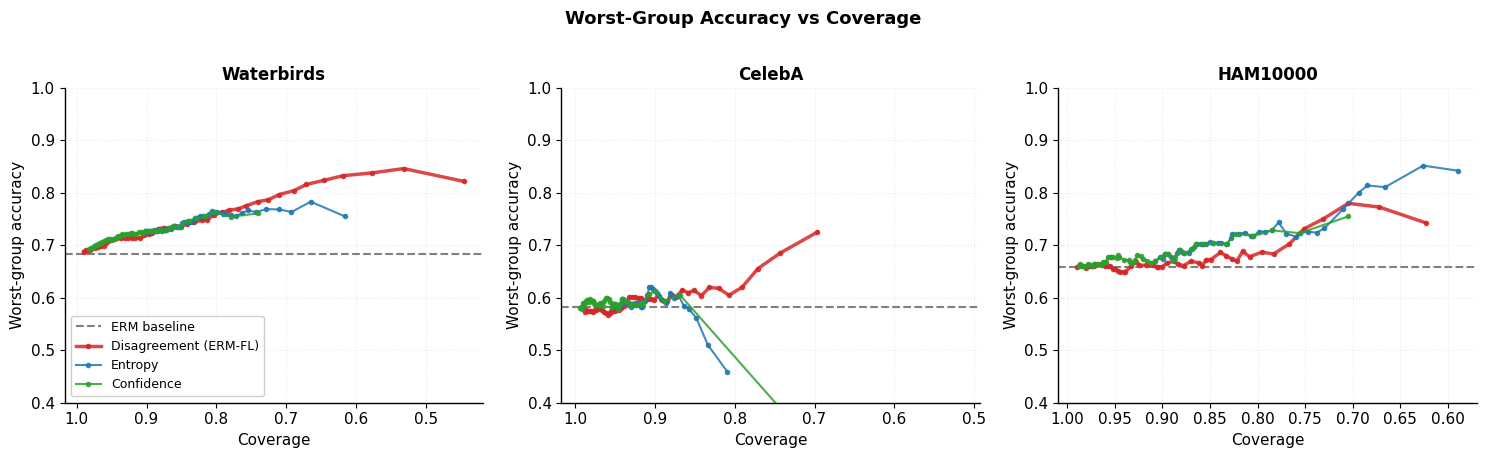


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Figure 4 — Error on Agreement vs Disagreement
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Saved /content/drive/MyDrive/paper_outputs/figure4_error_disagreement.pdf
  Saved /content/drive/MyDrive/paper_outputs/figure4_error_disagreement.png


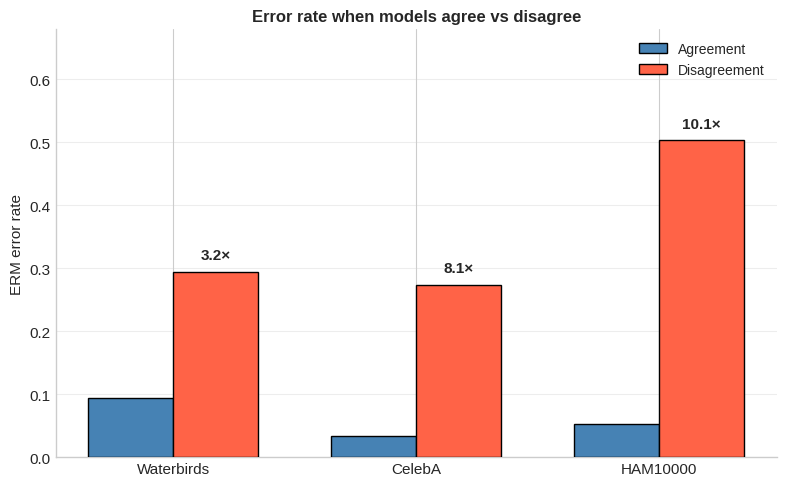


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Group Correlation Plot
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Correlation (ERM error vs disagreement): 0.890
  Saved /content/drive/MyDrive/paper_outputs/group_disagreement_correlation.pdf
  Saved /content/drive/MyDrive/paper_outputs/group_disagreement_correlation.png


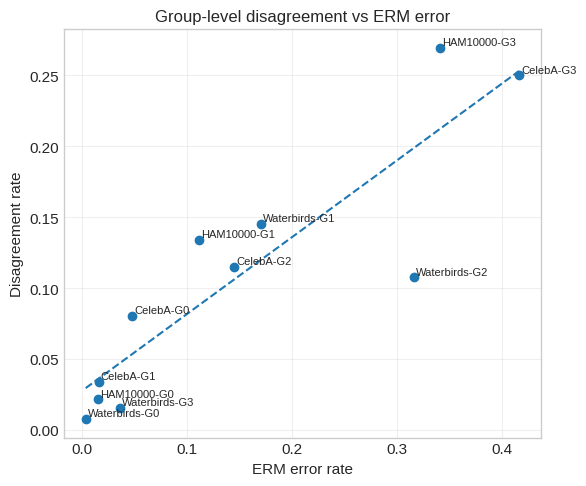


════════════════════════════════════════════════════════════
  ✓  All tables printed above.
  ✓  Figures saved to: /content/drive/MyDrive/paper_outputs
════════════════════════════════════════════════════════════


In [ ]:
"""
paper_results.py
════════════════════════════════════════════════════════════════════════════
Single script producing all tables and figures for the IntelliSys paper.

Tables:
  Table 1 — Coverage-Matched WGA          (main result)
  Table 2 — Complementarity Ablation      (ERM-FL vs ERM-ERM)
  Table 3 — Error-Detection AUC
  Table 4 — Error Concentration on Disagreement

Figures (saved as PDF + PNG to OUTPUT_DIR):
  Figure 1 — WGA vs Coverage curves
  Figure 4 — Error rate: Agreement vs Disagreement

Usage in Colab:
  1. Run this script — it mounts Google Drive automatically.
  2. Edit the SEEDS block with your actual CSV paths.
  3. Run: !python paper_results.py
     (or paste into a cell and execute)
"""

# # ── Mount Google Drive (Colab only) ──────────────────────────────────────
# try:
#     from google.colab import drive
#     drive.mount("/content/drive", force_remount=False)
#     print("Google Drive mounted.")
# except ImportError:
#     print("Not in Colab — skipping Drive mount.")

# ── Imports ───────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
})

# ════════════════════════════════════════════════════════════════════════════
#  ①  CONFIGURATION — Edit this block only
# ════════════════════════════════════════════════════════════════════════════

SEEDS = {
    "Waterbirds": {
        # erm_fl: list of (erm_csv, fl_csv) — one tuple per FL seed
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_456.csv",
            ),
        ],
        # erm_erm: single (erm_backbone_1, erm_backbone_2) pair for ablation
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
            "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
        ),
    },
    "CelebA": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
            "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
        ),
    },
    "HAM10000": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": (
            "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
            "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
        ),
    },
}

# Minimum coverage constraint for threshold selection
MIN_COVERAGE = 0.50

# Grid resolution for threshold sweeps
N_THRESHOLDS = 50

# Output directory for figures (on Drive so they survive runtime resets)
OUTPUT_DIR = "/content/drive/MyDrive/paper_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
#  ②  CORE EVAL FUNCTIONS  (self-contained; no external eval.py needed)
# ════════════════════════════════════════════════════════════════════════════

def _normalize_fl_columns(fl_df):
    """Accept FL CSVs with either 'prediction'/'confidence' or 'fl_prediction'/'fl_confidence'."""
    fl = fl_df.copy()
    if "prediction" not in fl.columns and "fl_prediction" in fl.columns:
        fl = fl.rename(columns={"fl_prediction": "prediction"})
    if "confidence" not in fl.columns and "fl_confidence" in fl.columns:
        fl = fl.rename(columns={"fl_confidence": "confidence"})
    missing = [c for c in ["image_id", "prediction", "confidence"] if c not in fl.columns]
    if missing:
        raise ValueError(f"FL CSV missing columns: {missing}")
    return fl[["image_id", "prediction", "confidence"]]


def load_and_merge(erm_csv, fl_csv):
    """Merge ERM and FL prediction CSVs on image_id."""
    erm = pd.read_csv(erm_csv)
    fl  = pd.read_csv(fl_csv)
    fl  = _normalize_fl_columns(fl)

    df = erm.merge(fl, on="image_id", how="inner", suffixes=("_x", "_y"))

    # Handle both pre-suffixed and plain column names after merge
    renames = {}
    for col in df.columns:
        if col == "prediction_x":  renames[col] = "erm_prediction"
        elif col == "prediction_y": renames[col] = "fl_prediction"
        elif col == "confidence_x": renames[col] = "erm_confidence"
        elif col == "confidence_y": renames[col] = "fl_confidence"
    df = df.rename(columns=renames)

    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Merged frame missing columns: {missing}. Available: {list(df.columns)}")
    return df


def load_and_merge_erm_erm(erm1_csv, erm2_csv):
    """Load two independent ERM CSVs; treat model 2 as the 'FL' for scoring."""
    erm1 = pd.read_csv(erm1_csv)
    erm2 = pd.read_csv(erm2_csv)[["image_id", "prediction", "confidence"]].rename(
        columns={"prediction": "fl_prediction", "confidence": "fl_confidence"}
    )
    df = erm1.merge(erm2, on="image_id", how="inner").rename(
        columns={"prediction": "erm_prediction", "confidence": "erm_confidence"}
    )
    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"ERM-ERM merge missing columns: {missing}")
    return df


def add_scores(df):
    """Add disagreement, entropy, and confidence scores to a merged DataFrame."""
    out = df.copy()
    eps = 1e-12
    p = out["erm_confidence"].clip(eps, 1 - eps)
    out["score_disagreement"] = (out["erm_confidence"] - out["fl_confidence"]).abs()
    out["score_entropy"]      = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    out["score_confidence"]   = 1 - out["erm_confidence"]
    out["error"]              = (out["erm_prediction"] != out["label"]).astype(int)
    return out


def compute_wga(df):
    """Worst-group accuracy of the ERM model on df."""
    return float((df["erm_prediction"] == df["label"]).groupby(df["group"]).mean().min())


def eval_abstention(df, score_col, thresholds):
    """Sweep thresholds for a single score column; return DataFrame of (threshold, coverage, wga)."""
    expected_groups = set(df["group"].unique())
    records = []
    for t in thresholds:
        retained = df[df[score_col] <= t]
        coverage = len(retained) / len(df)
        if retained.empty or set(retained["group"].unique()) != expected_groups:
            wga = np.nan
        else:
            wga = compute_wga(retained)
        records.append({"threshold": float(t), "coverage": float(coverage), "wga": wga})
    return pd.DataFrame(records)


def select_best_tau(results_df, min_coverage=0.5):
    """Return threshold that maximises WGA subject to coverage >= min_coverage."""
    valid = results_df.dropna(subset=["wga"])
    valid = valid[valid["coverage"] >= min_coverage]
    if valid.empty:
        raise ValueError("No valid threshold satisfies the coverage constraint.")
    return float(valid.loc[valid["wga"].idxmax(), "threshold"])


def coverage_matched_wga(df, target_cov, score_col, n_thr=200):
    """
    Find WGA at the threshold whose coverage is *closest* to target_cov.
    Returns (wga, actual_coverage, threshold).
    """
    thr = np.linspace(0, float(df[score_col].quantile(0.995)), n_thr)
    expected_groups = set(df["group"].unique())
    best_wga = best_cov = best_tau = np.nan
    best_diff = np.inf
    for t in thr:
        retained = df[df[score_col] <= t]
        cov = len(retained) / len(df)
        diff = abs(cov - target_cov)
        if diff < best_diff and not retained.empty \
                and set(retained["group"].unique()) == expected_groups:
            best_diff, best_wga, best_cov, best_tau = diff, compute_wga(retained), cov, float(t)
    return best_wga, best_cov, best_tau


def compute_auc(df):
    """AUROC for predicting ERM errors with each uncertainty score."""
    y = df["error"]
    if y.nunique() < 2:
        return {"disagreement": np.nan, "entropy": np.nan, "confidence": np.nan}
    return {
        "disagreement": roc_auc_score(y, df["score_disagreement"]),
        "entropy":      roc_auc_score(y, df["score_entropy"]),
        "confidence":   roc_auc_score(y, df["score_confidence"]),
    }

def compute_group_stats(df):
    """
    Returns per-group:
      - ERM accuracy
      - FL accuracy
      - disagreement rate
      - post-abstention accuracy (using disagreement threshold)
    """
    results = []

    # Use same threshold logic as main method
    thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
    res = eval_abstention(df, "score_disagreement", thr)
    tau = select_best_tau(res, MIN_COVERAGE)

    for g in sorted(df["group"].unique()):
        gdf = df[df["group"] == g]

        erm_acc = (gdf["erm_prediction"] == gdf["label"]).mean()
        fl_acc  = (gdf["fl_prediction"] == gdf["label"]).mean()

        disagree = (gdf["erm_prediction"] != gdf["fl_prediction"]).mean()

        retained = gdf[gdf["score_disagreement"] <= tau]
        if len(retained) > 0:
            post_acc = (retained["erm_prediction"] == retained["label"]).mean()
        else:
            post_acc = np.nan

        results.append({
            "group": g,
            "erm_acc": erm_acc,
            "fl_acc": fl_acc,
            "disagree_rate": disagree,
            "post_acc": post_acc
        })

    return pd.DataFrame(results)


def compute_error_concentration(erm_csv, fl_csv):
    """
    P(ERM error | agree) vs P(ERM error | disagree) and their ratio.
    Agreement is defined by *label* prediction match between ERM and FL.
    """
    df = load_and_merge(erm_csv, fl_csv)
    df["agree"] = df["erm_prediction"] == df["fl_prediction"]
    df["error"] = df["erm_prediction"] != df["label"]
    n_a, n_d   = df["agree"].sum(), (~df["agree"]).sum()
    err_a = float((df["error"] & df["agree"]).sum() / n_a)  if n_a > 0 else np.nan
    err_d = float((df["error"] & ~df["agree"]).sum() / n_d) if n_d > 0 else np.nan
    ratio = err_d / err_a if (err_a and err_a > 0) else np.nan
    return {"err_agree": err_a, "err_disagree": err_d, "ratio": ratio}


# ── Formatting helpers ─────────────────────────────────────────────────────

def ms(vals):
    """'mean ± std' string, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}" if v else "N/A"

def mo(vals):
    """Mean only, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan


# ════════════════════════════════════════════════════════════════════════════
#  ③  MAIN AGGREGATION LOOP
# ════════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())
all_results = {}

for dataset in DATASETS:
    print(f"\n{'━'*60}")
    print(f"  Processing: {dataset}")
    print(f"{'━'*60}")

    b = {k: [] for k in [
        "erm_wga",
        # Table 1 — coverage-matched WGA
        "cm_wga_dis", "cm_cov_dis",
        "cm_wga_ent", "cm_cov_ent",
        "cm_wga_conf", "cm_cov_conf",
        # Table 3 — AUC
        "auc_dis", "auc_ent", "auc_conf",
        # Table 4 — error concentration
        "err_agree", "err_disagree", "err_ratio",
    ]}
    # Figure 1 sweep (stored from first valid seed)
    b["sweep_dis"] = b["sweep_ent"] = b["sweep_conf"] = None
    # Table 2 — ERM-ERM ablation scalars
    b["erm_erm_best_wga"] = None
    b["erm_erm_auc_dis"]  = None

    # ── ERM-FL seeds ──────────────────────────────────────────────────────
    for i, (erm_csv, fl_csv) in enumerate(SEEDS[dataset]["erm_fl"]):
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP seed {i}] file not found:\n    {erm_csv}\n    {fl_csv}")
            continue
        print(f"  Seed {i} … ", end="", flush=True)

        df  = add_scores(load_and_merge(erm_csv, fl_csv))
        thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)

        # ERM baseline WGA (once, from first available seed)
        if not b["erm_wga"]:
            b["erm_wga"].append(compute_wga(df))

        # AUC (Table 3)
        aucs = compute_auc(df)
        b["auc_dis"].append(aucs["disagreement"])
        b["auc_ent"].append(aucs["entropy"])
        b["auc_conf"].append(aucs["confidence"])

        # Error concentration (Table 4)
        ec = compute_error_concentration(erm_csv, fl_csv)
        b["err_agree"].append(ec["err_agree"])
        b["err_disagree"].append(ec["err_disagree"])
        b["err_ratio"].append(ec["ratio"])

        # Coverage-matched WGA (Table 1)
        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau_dis    = select_best_tau(res_dis, MIN_COVERAGE)
            target_cov = float(res_dis.loc[
                np.isclose(res_dis["threshold"], tau_dis), "coverage"
            ].iloc[0])

            # Disagreement at its own best threshold
            best_dis_row = res_dis[np.isclose(res_dis["threshold"], tau_dis)].iloc[0]
            b["cm_wga_dis"].append(float(best_dis_row["wga"]))
            b["cm_cov_dis"].append(target_cov)

            # Entropy and Confidence at matched coverage
            wga_ent,  cov_ent,  _ = coverage_matched_wga(df, target_cov, "score_entropy")
            wga_conf, cov_conf, _ = coverage_matched_wga(df, target_cov, "score_confidence")
            b["cm_wga_ent"].append(wga_ent);   b["cm_cov_ent"].append(cov_ent)
            b["cm_wga_conf"].append(wga_conf); b["cm_cov_conf"].append(cov_conf)
        except ValueError as e:
            print(f"\n  [WARN seed {i}] {e}")
            for key in ["cm_wga_dis","cm_cov_dis","cm_wga_ent",
                        "cm_cov_ent","cm_wga_conf","cm_cov_conf"]:
                b[key].append(np.nan)

        # Store sweep data from first valid seed for Figure 1
        if b["sweep_dis"] is None:
            b["sweep_dis"]  = eval_abstention(df, "score_disagreement", thr)
            b["sweep_ent"]  = eval_abstention(df, "score_entropy",      thr)
            b["sweep_conf"] = eval_abstention(df, "score_confidence",   thr)

        print("done")

    # ── ERM-ERM ablation ─────────────────────────────────────────────────
    erm1, erm2 = SEEDS[dataset]["erm_erm"]
    if os.path.exists(erm1) and os.path.exists(erm2):
        print(f"  ERM-ERM … ", end="", flush=True)
        df_ee     = add_scores(load_and_merge_erm_erm(erm1, erm2))
        aucs_ee   = compute_auc(df_ee)
        b["erm_erm_auc_dis"] = aucs_ee["disagreement"]

        thr_ee  = np.linspace(0, float(df_ee["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        res_ee  = eval_abstention(df_ee, "score_disagreement", thr_ee)
        valid   = res_ee.dropna(subset=["wga"])
        if not valid.empty:
            b["erm_erm_best_wga"] = float(valid.loc[valid["wga"].idxmax(), "wga"])
        print("done")
    else:
        print(f"  [SKIP ERM-ERM] files not found for {dataset}")

    # ── Per-group table (Table 6 style) ───────────────────────────────
    print(f"\n  Per-group analysis — {dataset}")
    print("  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc")

    # Use first seed for interpretability (consistent with figures)
    erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
    df = add_scores(load_and_merge(erm_csv, fl_csv))

    gstats = compute_group_stats(df)

    for _, row in gstats.iterrows():
        print(
            f"  G{int(row['group'])} | "
            f"{row['erm_acc']*100:6.1f}% | "
            f"{row['fl_acc']*100:6.1f}% | "
            f"{row['disagree_rate']*100:6.1f}% | "
            f"{row['post_acc']*100:6.1f}%"
        )

    all_results[dataset] = b


# ════════════════════════════════════════════════════════════════════════════
#  ④  PRINT TABLES
# ════════════════════════════════════════════════════════════════════════════

BAR = "═" * 88

# ── Table 1 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 1 — Coverage-Matched Worst-Group Accuracy (mean ± std, 3 seeds)")
print("  Entropy and Confidence evaluated at the same coverage as Disagreement's best τ.")
print(BAR)
hdr = (f"{'Dataset':<12}  {'ERM Baseline':>14}  "
       f"{'Dis WGA':>18}  {'Cov':>7}  "
       f"{'Ent WGA':>18}  {'Conf WGA':>18}")
print(hdr)
print("-" * 90)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['erm_wga']):>14}  "
        f"{ms(b['cm_wga_dis']):>18}  {ms(b['cm_cov_dis']):>7}  "
        f"{ms(b['cm_wga_ent']):>18}  {ms(b['cm_wga_conf']):>18}"
    )

# ── Table 2 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 2 — Complementarity Ablation: ERM-FL vs ERM-ERM Disagreement")
print("  ERM-FL: mean ± std over 3 FL seeds   |   ERM-ERM: single pair of ERM backbones")
print(BAR)
print(f"{'Dataset':<12}  {'Metric':<16}  {'ERM-FL (n=3)':>22}  {'ERM-ERM (n=1)':>16}  {'Δ (FL − ERM)':>14}")
print("-" * 84)
for d in DATASETS:
    b = all_results[d]
    # Best WGA row
    fl_wga = mo(b["cm_wga_dis"])
    ee_wga = b["erm_erm_best_wga"]
    dw_str = f"{fl_wga - ee_wga:+.4f}" if ee_wga is not None and not np.isnan(fl_wga) else "N/A"
    ee_wga_str = f"{ee_wga:.4f}" if ee_wga is not None else "N/A"
    print(f"{d:<12}  {'Best WGA':<16}  {ms(b['cm_wga_dis']):>22}  {ee_wga_str:>16}  {dw_str:>14}")

    # AUC row
    fl_auc = mo(b["auc_dis"])
    ee_auc = b["erm_erm_auc_dis"]
    da_str = f"{fl_auc - ee_auc:+.4f}" if ee_auc is not None and not np.isnan(fl_auc) else "N/A"
    ee_auc_str = f"{ee_auc:.4f}" if ee_auc is not None else "N/A"
    print(f"{d:<12}  {'Error-Det AUC':<16}  {ms(b['auc_dis']):>22}  {ee_auc_str:>16}  {da_str:>14}")
    print()

# ── Table 3 ───────────────────────────────────────────────────────────────
print(f"\n{BAR}")
print("  TABLE 3 — Error-Detection AUC / AUROC (mean ± std, 3 seeds)")
print("  Higher AUC = better at identifying ERM errors from uncertainty score.")
print(BAR)
print(f"{'Dataset':<12}  {'Disagreement':>20}  {'Entropy':>20}  {'Confidence':>20}")
print("-" * 76)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['auc_dis']):>20}  "
        f"{ms(b['auc_ent']):>20}  {ms(b['auc_conf']):>20}"
    )

# ── Table 4 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 4 — Error Concentration: Agreement vs Disagreement (mean ± std, 3 seeds)")
print("  Ratio = P(ERM error | disagree) / P(ERM error | agree).")
print(BAR)
print(f"{'Dataset':<12}  {'Err | Agree':>18}  {'Err | Disagree':>18}  {'Ratio (×)':>12}")
print("-" * 64)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['err_agree']):>18}  "
        f"{ms(b['err_disagree']):>18}  {ms(b['err_ratio']):>12}"
    )

# ── Delta summary ─────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  SUMMARY — WGA improvement: Disagreement vs ERM baseline")
print(BAR)
for d in DATASETS:
    b = all_results[d]
    erm = mo(b["erm_wga"])
    dis = mo(b["cm_wga_dis"])
    delta = dis - erm if not np.isnan(erm + dis) else np.nan
    print(
        f"  {d:<12}  ERM={erm:.4f}  →  Dis={dis:.4f}  "
        f"Δ = {delta:+.4f} ({delta * 100:+.1f} pp)"
    )


# ════════════════════════════════════════════════════════════════════════════
#  ⑤  FIGURE 1 — WGA vs Coverage
# ════════════════════════════════════════════════════════════════════════════

def generate_figure1(all_results, datasets, erm_wgas, output_dir):
    """
    Three-panel plot: WGA vs Coverage for each dataset.
    Uses sweep data from the first available FL seed per dataset.
    """
    colors  = {"disagreement": "#d62728", "entropy": "#1f77b4", "confidence": "#2ca02c"}
    labels  = {"disagreement": "Disagreement (ERM-FL)", "entropy": "Entropy", "confidence": "Confidence"}
    sweeps  = {
        "disagreement": "sweep_dis",
        "entropy":      "sweep_ent",
        "confidence":   "sweep_conf",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, dataset in zip(axes, datasets):
        b = all_results[dataset]
        erm_wga = erm_wgas[dataset]

        # ERM baseline horizontal line
        ax.axhline(erm_wga, color="grey", linestyle="--", linewidth=1.5,
                   label="ERM baseline", zorder=1)

        for method, sweep_key in sweeps.items():
            sweep = b[sweep_key]
            if sweep is None:
                continue
            data = sweep.dropna(subset=["wga"]).sort_values("coverage")
            lw = 2.5 if method == "disagreement" else 1.5
            ax.plot(
                data["coverage"], data["wga"],
                color=colors[method], linewidth=lw,
                label=labels[method], marker="o", markersize=3, alpha=0.85,
            )

        ax.set_xlabel("Coverage", fontsize=11)
        ax.set_ylabel("Worst-group accuracy", fontsize=11)
        ax.set_title(dataset, fontsize=12, fontweight="bold")
        ax.invert_xaxis()
        ax.set_ylim(0.4, 1.0)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Single shared legend on leftmost panel
    axes[0].legend(loc="lower left", fontsize=9, framealpha=0.95)

    plt.suptitle("Worst-Group Accuracy vs Coverage", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure1_wga_vs_coverage.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑥  FIGURE 4 — Error on Agreement vs Disagreement
# ════════════════════════════════════════════════════════════════════════════

def generate_figure4(all_results, datasets, output_dir):
    """
    Grouped bar chart: ERM error rate when models agree vs disagree.
    Ratio annotation above the Disagreement bar.
    """
    plt.style.use("seaborn-v0_8-whitegrid")

    err_agree    = [mo(all_results[d]["err_agree"])    for d in datasets]
    err_disagree = [mo(all_results[d]["err_disagree"]) for d in datasets]
    ratios       = [mo(all_results[d]["err_ratio"])    for d in datasets]

    x     = np.arange(len(datasets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(x - width / 2, err_agree,    width, color="steelblue", edgecolor="black",
           label="Agreement",    zorder=3)
    bars_dis = ax.bar(x + width / 2, err_disagree, width, color="tomato",    edgecolor="black",
                      label="Disagreement", zorder=3)

    # Ratio annotations
    for bar, ratio in zip(bars_dis, ratios):
        if np.isfinite(ratio):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{ratio:.1f}×",
                ha="center", va="bottom", fontsize=11, fontweight="bold",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel("ERM error rate", fontsize=11)
    ax.set_title("Error rate when models agree vs disagree", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(err_disagree) * 1.25 + 0.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")
    ax.yaxis.grid(True, alpha=0.35)
    ax.set_axisbelow(True)

    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure4_error_disagreement.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)

def generate_group_correlation_plot(SEEDS, output_dir):
    """
    Scatter: ERM error rate vs disagreement rate (per group, all datasets)
    """

    xs = []  # ERM error
    ys = []  # disagreement
    labels = []

    for dataset in SEEDS:
        erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        for g in sorted(df["group"].unique()):
            gdf = df[df["group"] == g]

            erm_acc = (gdf["erm_prediction"] == gdf["label"]).mean()
            erm_error = 1 - erm_acc

            disagree = (gdf["erm_prediction"] != gdf["fl_prediction"]).mean()

            xs.append(erm_error)
            ys.append(disagree)
            labels.append(f"{dataset}-G{g}")

    # Plot
    plt.figure(figsize=(6, 5))

    plt.scatter(xs, ys)

    # Annotate points
    for x, y, label in zip(xs, ys, labels):
        plt.text(x + 0.002, y + 0.002, label, fontsize=8)

    # Fit line
    if len(xs) > 1:
        coef = np.polyfit(xs, ys, 1)
        x_line = np.linspace(min(xs), max(xs), 100)
        y_line = coef[0] * x_line + coef[1]
        plt.plot(x_line, y_line, linestyle="--")

        corr = np.corrcoef(xs, ys)[0, 1]
        print(f"  Correlation (ERM error vs disagreement): {corr:.3f}")

    plt.xlabel("ERM error rate")
    plt.ylabel("Disagreement rate")
    plt.title("Group-level disagreement vs ERM error")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"group_disagreement_correlation.{ext}")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")

    plt.show()
    plt.close()

# ════════════════════════════════════════════════════════════════════════════
#  ⑦  GENERATE FIGURES
# ════════════════════════════════════════════════════════════════════════════

# ERM baseline WGA dict for Figure 1 horizontal line
erm_wga_dict = {d: mo(all_results[d]["erm_wga"]) for d in DATASETS}

print(f"\n\n{'━'*60}")
print("  Generating Figure 1 — WGA vs Coverage")
print(f"{'━'*60}")
generate_figure1(all_results, DATASETS, erm_wga_dict, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Figure 4 — Error on Agreement vs Disagreement")
print(f"{'━'*60}")
generate_figure4(all_results, DATASETS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Group Correlation Plot")
print(f"{'━'*60}")
generate_group_correlation_plot(SEEDS, OUTPUT_DIR)

print(f"\n{'═'*60}")
print("  ✓  All tables printed above.")
print(f"  ✓  Figures saved to: {OUTPUT_DIR}")
print(f"{'═'*60}")

In [ ]:
erm_csv = "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv"
fl_csv  = "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv"

df = add_scores(load_and_merge(erm_csv, fl_csv))

thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), 50)

res_dis = eval_abstention(df, "score_disagreement", thr)
tau_dis = select_best_tau(res_dis, min_coverage=0.5)

target_cov = float(
    res_dis.loc[np.isclose(res_dis["threshold"], tau_dis), "coverage"].iloc[0]
)

print("Target coverage (from disagreement):", target_cov)

wga_ent, cov_ent, tau_ent = coverage_matched_wga(
    df, target_cov, "score_entropy"
)

print("Entropy matched coverage:", cov_ent)
print("Entropy WGA:", wga_ent)
print("Entropy threshold:", tau_ent)

retained_ent = df[df["score_entropy"] <= tau_ent]
retained_dis = df[df["score_disagreement"] <= tau_dis]

print("\nEntropy retained group counts:")
print(retained_ent["group"].value_counts())

print("\nDisagreement retained group counts:")
print(retained_dis["group"].value_counts())

print("\nEntropy per-group accuracy:")
print(
    retained_ent.groupby("group")
    .apply(lambda x: (x["erm_prediction"] == x["label"]).mean())
)

print("\nDisagreement per-group accuracy:")
print(
    retained_dis.groupby("group")
    .apply(lambda x: (x["erm_prediction"] == x["label"]).mean())
)

print("\nOriginal group counts:")
print(df["group"].value_counts(normalize=True))

print("\nEntropy retained distribution:")
print(retained_ent["group"].value_counts(normalize=True))

print("\nDisagreement retained distribution:")
print(retained_dis["group"].value_counts(normalize=True))

Target coverage (from disagreement): 0.6966736799919848
Entropy matched coverage: 0.7789800621180243
Entropy WGA: 0.37037037037037035
Entropy threshold: 0.0034636287323421616

Entropy retained group counts:
group
0    8155
1    6700
2     668
3      27
Name: count, dtype: int64

Disagreement retained group counts:
group
0    6633
1    6022
2    1212
3      40
Name: count, dtype: int64

Entropy per-group accuracy:
group
0    0.996321
1    1.000000
2    0.914671
3    0.370370
dtype: float64

Disagreement per-group accuracy:
group
0    0.987487
1    0.998838
2    0.977723
3    0.725000
dtype: float64

Original group counts:
group
0    0.489280
1    0.377467
2    0.124236
3    0.009017
Name: proportion, dtype: float64

Entropy retained distribution:
group
0    0.524437
1    0.430868
2    0.042958
3    0.001736
Name: proportion, dtype: float64

Disagreement retained distribution:
group
0    0.476954
1    0.433019
2    0.087150
3    0.002876
Name: proportion, dtype: float64



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: Waterbirds
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — Waterbirds
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   99.6% |   99.4% |    0.8% |   99.9%
  G1 |   82.9% |   71.6% |   14.5% |   84.6%
  G2 |   68.4% |   74.1% |   10.7% |   85.4%
  G3 |   96.4% |   97.0% |    1.6% |   99.6%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: CelebA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — CelebA
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   95.2% |   88.4% |    8.0% |   98.7%
  G1 |   98.4% |   96.4% |    3.3% |   99.9

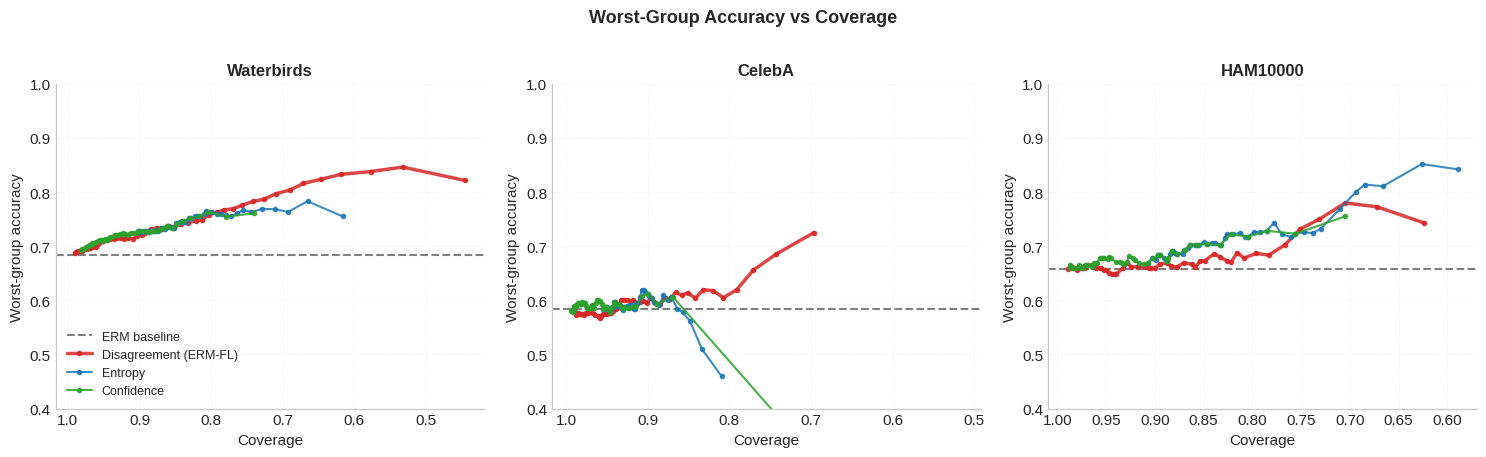


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Figure 4 — Error on Agreement vs Disagreement
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.png


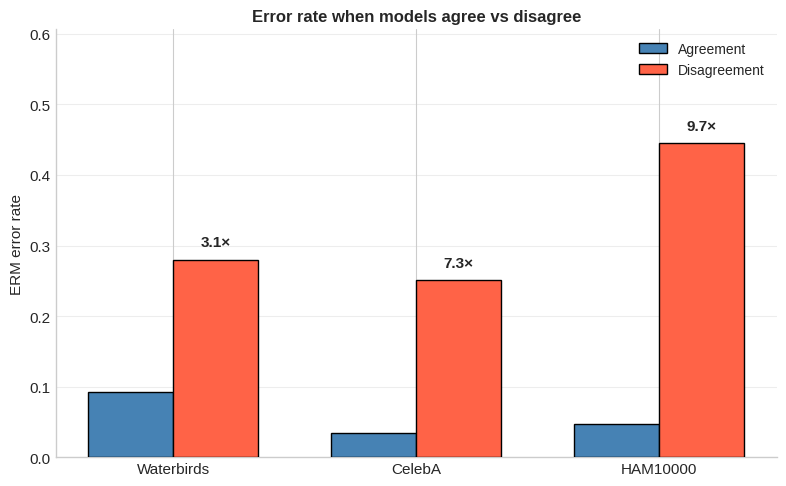


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Group Correlation Plot
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Correlation (ERM error vs disagreement): 0.890
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.png


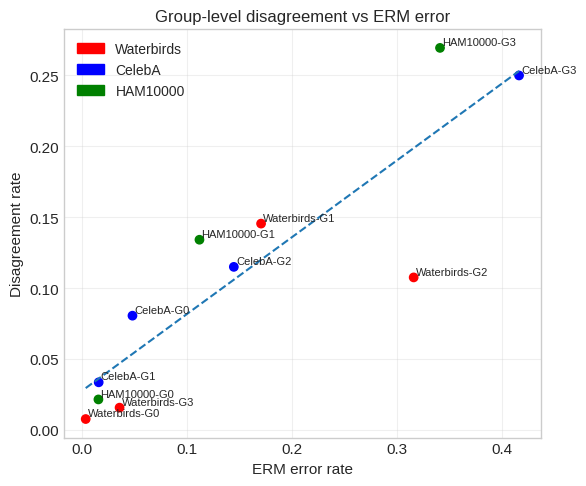


════════════════════════════════════════════════════════════
  ✓  All tables printed above.
  ✓  Figures saved to: /content/drive/MyDrive/TDL/paper_outputs
════════════════════════════════════════════════════════════


In [ ]:
"""
paper_results.py
════════════════════════════════════════════════════════════════════════════
Single script producing all tables and figures for the IntelliSys paper.

Tables:
  Table 1 — Coverage-Matched WGA          (main result)
  Table 2 — Complementarity Ablation      (ERM-FL vs ERM-ERM, both n=3)
  Table 3 — Error-Detection AUC
  Table 4 — Error Concentration on Disagreement

Figures (saved as PDF + PNG to OUTPUT_DIR):
  Figure 1 — WGA vs Coverage curves
  Figure 4 — Error rate: Agreement vs Disagreement

Usage in Colab:
  1. Run this script — it mounts Google Drive automatically.
  2. Edit the SEEDS block with your actual CSV paths.
  3. Run: !python paper_results.py
     (or paste into a cell and execute)
"""

# # ── Mount Google Drive (Colab only) ──────────────────────────────────────
# try:
#     from google.colab import drive
#     drive.mount("/content/drive", force_remount=False)
#     print("Google Drive mounted.")
# except ImportError:
#     print("Not in Colab — skipping Drive mount.")

# ── Imports ───────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
})

# ════════════════════════════════════════════════════════════════════════════
#  ①  CONFIGURATION — Edit this block only
# ════════════════════════════════════════════════════════════════════════════

SEEDS = {
    "Waterbirds": {
        # erm_fl: list of (erm_csv, fl_csv) — one tuple per FL seed (42, 123, 456)
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_456.csv",
            ),
        ],
        # erm_erm: 3 pairs of independent ERM seeds — matched n=3 to ERM-FL
        # Pairs: (seed42,seed123), (seed123,seed456), (seed42,seed456)
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "CelebA": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "HAM10000": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
        ],
    },
}

# Minimum coverage constraint for threshold selection
MIN_COVERAGE = 0.50

# Grid resolution for threshold sweeps
N_THRESHOLDS = 50

# Output directory for figures (on Drive so they survive runtime resets)
OUTPUT_DIR = "/content/drive/MyDrive/TDL/paper_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
#  ②  CORE EVAL FUNCTIONS  (self-contained; no external eval.py needed)
# ════════════════════════════════════════════════════════════════════════════

def _normalize_fl_columns(fl_df):
    """Accept FL CSVs with either 'prediction'/'confidence' or 'fl_prediction'/'fl_confidence'."""
    fl = fl_df.copy()
    if "prediction" not in fl.columns and "fl_prediction" in fl.columns:
        fl = fl.rename(columns={"fl_prediction": "prediction"})
    if "confidence" not in fl.columns and "fl_confidence" in fl.columns:
        fl = fl.rename(columns={"fl_confidence": "confidence"})
    missing = [c for c in ["image_id", "prediction", "confidence"] if c not in fl.columns]
    if missing:
        raise ValueError(f"FL CSV missing columns: {missing}")
    return fl[["image_id", "prediction", "confidence"]]


def load_and_merge(erm_csv, fl_csv):
    """Merge ERM and FL prediction CSVs on image_id."""
    erm = pd.read_csv(erm_csv)
    fl  = pd.read_csv(fl_csv)
    fl  = _normalize_fl_columns(fl)

    df = erm.merge(fl, on="image_id", how="inner", suffixes=("_x", "_y"))

    renames = {}
    for col in df.columns:
        if col == "prediction_x":   renames[col] = "erm_prediction"
        elif col == "prediction_y": renames[col] = "fl_prediction"
        elif col == "confidence_x": renames[col] = "erm_confidence"
        elif col == "confidence_y": renames[col] = "fl_confidence"
    df = df.rename(columns=renames)

    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Merged frame missing columns: {missing}. Available: {list(df.columns)}")
    return df


def load_and_merge_erm_erm(erm1_csv, erm2_csv):
    """
    Load two independent ERM CSVs.
    Model 1 is treated as 'ERM' (primary model whose errors we predict).
    Model 2 plays the structural 'FL' role for disagreement scoring.
    """
    erm1 = pd.read_csv(erm1_csv)
    erm2 = pd.read_csv(erm2_csv)[["image_id", "prediction", "confidence"]].rename(
        columns={"prediction": "fl_prediction", "confidence": "fl_confidence"}
    )
    df = erm1.merge(erm2, on="image_id", how="inner").rename(
        columns={"prediction": "erm_prediction", "confidence": "erm_confidence"}
    )
    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"ERM-ERM merge missing columns: {missing}")
    return df


def add_scores(df):
    """Add disagreement, entropy, and confidence scores to a merged DataFrame."""
    out = df.copy()
    eps = 1e-12
    p = out["erm_confidence"].clip(eps, 1 - eps)
    out["score_disagreement"] = (out["erm_confidence"] - out["fl_confidence"]).abs()
    out["score_entropy"]      = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    out["score_confidence"]   = 1 - out["erm_confidence"]
    out["error"]              = (out["erm_prediction"] != out["label"]).astype(int)
    return out


def compute_wga(df):
    """Worst-group accuracy of the ERM model on df."""
    return float((df["erm_prediction"] == df["label"]).groupby(df["group"]).mean().min())


def eval_abstention(df, score_col, thresholds):
    """Sweep thresholds; return DataFrame of (threshold, coverage, wga)."""
    expected_groups = set(df["group"].unique())
    records = []
    for t in thresholds:
        retained = df[df[score_col] <= t]
        coverage = len(retained) / len(df)
        if retained.empty or set(retained["group"].unique()) != expected_groups:
            wga = np.nan
        else:
            wga = compute_wga(retained)
        records.append({"threshold": float(t), "coverage": float(coverage), "wga": wga})
    return pd.DataFrame(records)


def select_best_tau(results_df, min_coverage=0.5):
    """Return threshold that maximises WGA subject to coverage >= min_coverage."""
    valid = results_df.dropna(subset=["wga"])
    valid = valid[valid["coverage"] >= min_coverage]
    if valid.empty:
        raise ValueError("No valid threshold satisfies the coverage constraint.")
    return float(valid.loc[valid["wga"].idxmax(), "threshold"])


def coverage_matched_wga(df, target_cov, score_col, n_thr=200):
    """Find WGA at the threshold whose coverage is closest to target_cov."""
    thr = np.linspace(0, float(df[score_col].quantile(0.995)), n_thr)
    expected_groups = set(df["group"].unique())
    best_wga = best_cov = best_tau = np.nan
    best_diff = np.inf
    for t in thr:
        retained = df[df[score_col] <= t]
        cov = len(retained) / len(df)
        diff = abs(cov - target_cov)
        if diff < best_diff and not retained.empty \
                and set(retained["group"].unique()) == expected_groups:
            best_diff, best_wga, best_cov, best_tau = diff, compute_wga(retained), cov, float(t)
    return best_wga, best_cov, best_tau


def compute_auc(df):
    """AUROC for predicting ERM errors with each uncertainty score."""
    y = df["error"]
    if y.nunique() < 2:
        return {"disagreement": np.nan, "entropy": np.nan, "confidence": np.nan}
    return {
        "disagreement": roc_auc_score(y, df["score_disagreement"]),
        "entropy":      roc_auc_score(y, df["score_entropy"]),
        "confidence":   roc_auc_score(y, df["score_confidence"]),
    }


def compute_group_stats(df):
    """Per-group: ERM acc, FL acc, disagreement rate, post-abstention acc."""
    results = []
    thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
    res = eval_abstention(df, "score_disagreement", thr)
    tau = select_best_tau(res, MIN_COVERAGE)

    for g in sorted(df["group"].unique()):
        gdf = df[df["group"] == g]
        erm_acc  = (gdf["erm_prediction"] == gdf["label"]).mean()
        fl_acc   = (gdf["fl_prediction"]  == gdf["label"]).mean()
        disagree = (gdf["erm_prediction"] != gdf["fl_prediction"]).mean()
        retained = gdf[gdf["score_disagreement"] <= tau]
        post_acc = (retained["erm_prediction"] == retained["label"]).mean() \
            if len(retained) > 0 else np.nan
        results.append({"group": g, "erm_acc": erm_acc, "fl_acc": fl_acc,
                        "disagree_rate": disagree, "post_acc": post_acc})
    return pd.DataFrame(results)


def compute_error_concentration(erm_csv, fl_csv):
    """P(ERM error | agree) vs P(ERM error | disagree) and their ratio."""
    df = load_and_merge(erm_csv, fl_csv)
    df["agree"] = df["erm_prediction"] == df["fl_prediction"]
    df["error"] = df["erm_prediction"] != df["label"]
    n_a, n_d = df["agree"].sum(), (~df["agree"]).sum()
    err_a = float((df["error"] & df["agree"]).sum()  / n_a) if n_a > 0 else np.nan
    err_d = float((df["error"] & ~df["agree"]).sum() / n_d) if n_d > 0 else np.nan
    ratio = err_d / err_a if (err_a and err_a > 0) else np.nan
    return {"err_agree": err_a, "err_disagree": err_d, "ratio": ratio}


# ── Formatting helpers ─────────────────────────────────────────────────────

def ms(vals):
    """'mean ± std' string, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}" if v else "N/A"

def mo(vals):
    """Mean only, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan


# ════════════════════════════════════════════════════════════════════════════
#  ③  MAIN AGGREGATION LOOP
# ════════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())
all_results = {}

for dataset in DATASETS:
    print(f"\n{'━'*60}")
    print(f"  Processing: {dataset}")
    print(f"{'━'*60}")

    b = {k: [] for k in [
        "erm_wga",
        "cm_wga_dis", "cm_cov_dis",
        "cm_wga_ent",  "cm_cov_ent",
        "cm_wga_conf", "cm_cov_conf",
        "auc_dis", "auc_ent", "auc_conf",
        "err_agree", "err_disagree", "err_ratio",
        # ERM-ERM ablation — now n=3 pairs, stored as lists (same as ERM-FL)
        "erm_erm_best_wga", "erm_erm_auc_dis",
    ]}
    b["sweep_dis"] = b["sweep_ent"] = b["sweep_conf"] = None

    # ── ERM-FL seeds ──────────────────────────────────────────────────────
    for i, (erm_csv, fl_csv) in enumerate(SEEDS[dataset]["erm_fl"]):
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP ERM-FL seed {i}] file not found:\n    {erm_csv}\n    {fl_csv}")
            continue
        print(f"  ERM-FL seed {i} … ", end="", flush=True)

        df  = add_scores(load_and_merge(erm_csv, fl_csv))
        thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)

        if not b["erm_wga"]:
            b["erm_wga"].append(compute_wga(df))

        aucs = compute_auc(df)
        b["auc_dis"].append(aucs["disagreement"])
        b["auc_ent"].append(aucs["entropy"])
        b["auc_conf"].append(aucs["confidence"])

        ec = compute_error_concentration(erm_csv, fl_csv)
        b["err_agree"].append(ec["err_agree"])
        b["err_disagree"].append(ec["err_disagree"])
        b["err_ratio"].append(ec["ratio"])

        res_dis = eval_abstention(df, "score_disagreement", thr)
        try:
            tau_dis    = select_best_tau(res_dis, MIN_COVERAGE)
            target_cov = float(res_dis.loc[
                np.isclose(res_dis["threshold"], tau_dis), "coverage"
            ].iloc[0])
            best_dis_row = res_dis[np.isclose(res_dis["threshold"], tau_dis)].iloc[0]
            b["cm_wga_dis"].append(float(best_dis_row["wga"]))
            b["cm_cov_dis"].append(target_cov)
            wga_ent,  cov_ent,  _ = coverage_matched_wga(df, target_cov, "score_entropy")
            wga_conf, cov_conf, _ = coverage_matched_wga(df, target_cov, "score_confidence")
            b["cm_wga_ent"].append(wga_ent);   b["cm_cov_ent"].append(cov_ent)
            b["cm_wga_conf"].append(wga_conf); b["cm_cov_conf"].append(cov_conf)
        except ValueError as e:
            print(f"\n  [WARN seed {i}] {e}")
            for key in ["cm_wga_dis","cm_cov_dis","cm_wga_ent",
                        "cm_cov_ent","cm_wga_conf","cm_cov_conf"]:
                b[key].append(np.nan)

        if b["sweep_dis"] is None:
            b["sweep_dis"]  = eval_abstention(df, "score_disagreement", thr)
            b["sweep_ent"]  = eval_abstention(df, "score_entropy",      thr)
            b["sweep_conf"] = eval_abstention(df, "score_confidence",   thr)

        print("done")

    # ── ERM-ERM ablation — 3 pairs, matched n=3 ──────────────────────────
    print(f"  ERM-ERM pairs … ", end="", flush=True)
    for pair_idx, (erm1_csv, erm2_csv) in enumerate(SEEDS[dataset]["erm_erm"]):
        if not (os.path.exists(erm1_csv) and os.path.exists(erm2_csv)):
            print(f"\n  [SKIP ERM-ERM pair {pair_idx}] file not found:\n    {erm1_csv}\n    {erm2_csv}")
            b["erm_erm_best_wga"].append(np.nan)
            b["erm_erm_auc_dis"].append(np.nan)
            continue

        df_ee   = add_scores(load_and_merge_erm_erm(erm1_csv, erm2_csv))
        aucs_ee = compute_auc(df_ee)
        b["erm_erm_auc_dis"].append(aucs_ee["disagreement"])

        thr_ee = np.linspace(0, float(df_ee["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        res_ee = eval_abstention(df_ee, "score_disagreement", thr_ee)
        valid  = res_ee.dropna(subset=["wga"])
        valid  = valid[valid["coverage"] >= MIN_COVERAGE]
        best   = float(valid.loc[valid["wga"].idxmax(), "wga"]) if not valid.empty else np.nan
        b["erm_erm_best_wga"].append(best)
        print(f"pair {pair_idx} done … ", end="", flush=True)
    print()

    # ── Per-group table ───────────────────────────────────────────────────
    print(f"\n  Per-group analysis — {dataset}")
    print("  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc")
    erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
    if os.path.exists(erm_csv) and os.path.exists(fl_csv):
        df = add_scores(load_and_merge(erm_csv, fl_csv))
        for _, row in compute_group_stats(df).iterrows():
            print(
                f"  G{int(row['group'])} | "
                f"{row['erm_acc']*100:6.1f}% | {row['fl_acc']*100:6.1f}% | "
                f"{row['disagree_rate']*100:6.1f}% | {row['post_acc']*100:6.1f}%"
            )

    all_results[dataset] = b


# ════════════════════════════════════════════════════════════════════════════
#  ④  PRINT TABLES
# ════════════════════════════════════════════════════════════════════════════

BAR = "═" * 92

# ── Table 1 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 1 — Coverage-Matched Worst-Group Accuracy (mean ± std, n=3)")
print("  Entropy and Confidence evaluated at the same coverage as Disagreement's best τ.")
print(BAR)
print(f"{'Dataset':<12}  {'ERM Baseline':>14}  {'Dis WGA':>18}  {'Cov':>7}  {'Ent WGA':>18}  {'Conf WGA':>18}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['erm_wga']):>14}  "
        f"{ms(b['cm_wga_dis']):>18}  {ms(b['cm_cov_dis']):>7}  "
        f"{ms(b['cm_wga_ent']):>18}  {ms(b['cm_wga_conf']):>18}"
    )

# ── Table 2 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 2 — Complementarity Ablation: ERM-FL vs ERM-ERM Disagreement")
print("  Both conditions: mean ± std over n=3 pairs.")
print("  ERM-FL:  (seed42,seed42), (seed42,seed123), (seed42,seed456)")
print("  ERM-ERM: (seed42,seed123), (seed123,seed456), (seed42,seed456)")
print(BAR)
print(f"{'Dataset':<12}  {'Metric':<16}  {'ERM-FL (n=3)':>22}  {'ERM-ERM (n=3)':>22}  {'Δ (FL−ERM)':>12}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    fl_wga = mo(b["cm_wga_dis"]);  ee_wga = mo(b["erm_erm_best_wga"])
    fl_auc = mo(b["auc_dis"]);     ee_auc = mo(b["erm_erm_auc_dis"])
    dw = f"{fl_wga - ee_wga:+.4f}" if not (np.isnan(fl_wga) or np.isnan(ee_wga)) else "N/A"
    da = f"{fl_auc - ee_auc:+.4f}" if not (np.isnan(fl_auc) or np.isnan(ee_auc)) else "N/A"
    print(f"{d:<12}  {'Best WGA':<16}  {ms(b['cm_wga_dis']):>22}  {ms(b['erm_erm_best_wga']):>22}  {dw:>12}")
    print(f"{d:<12}  {'Error-Det AUC':<16}  {ms(b['auc_dis']):>22}  {ms(b['erm_erm_auc_dis']):>22}  {da:>12}")
    print()

# ── Table 3 ───────────────────────────────────────────────────────────────
print(f"\n{BAR}")
print("  TABLE 3 — Error-Detection AUC / AUROC (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Disagreement':>20}  {'Entropy':>20}  {'Confidence':>20}")
print("-" * 76)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['auc_dis']):>20}  {ms(b['auc_ent']):>20}  {ms(b['auc_conf']):>20}")

# ── Table 4 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 4 — Error Concentration: Agreement vs Disagreement (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Err | Agree':>18}  {'Err | Disagree':>18}  {'Ratio (×)':>12}")
print("-" * 64)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['err_agree']):>18}  {ms(b['err_disagree']):>18}  {ms(b['err_ratio']):>12}")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  SUMMARY — WGA gain (Disagreement vs ERM baseline) and Ablation gap")
print(BAR)
for d in DATASETS:
    b = all_results[d]
    erm = mo(b["erm_wga"]);  dis = mo(b["cm_wga_dis"])
    ee  = mo(b["erm_erm_best_wga"])
    delta_erm = dis - erm if not np.isnan(dis + erm) else np.nan
    delta_ee  = dis - ee  if not np.isnan(dis + ee)  else np.nan
    print(
        f"  {d:<12}  vs ERM baseline: Δ={delta_erm:+.4f} ({delta_erm*100:+.1f} pp)"
        f"  |  vs ERM-ERM: Δ={delta_ee:+.4f} ({delta_ee*100:+.1f} pp)"
    )


# ════════════════════════════════════════════════════════════════════════════
#  ⑤  FIGURE 1 — WGA vs Coverage
# ════════════════════════════════════════════════════════════════════════════

def generate_figure1(all_results, datasets, erm_wgas, output_dir):
    colors = {"disagreement": "#d62728", "entropy": "#1f77b4", "confidence": "#2ca02c"}
    labels = {"disagreement": "Disagreement (ERM-FL)", "entropy": "Entropy", "confidence": "Confidence"}
    sweeps = {"disagreement": "sweep_dis", "entropy": "sweep_ent", "confidence": "sweep_conf"}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, dataset in zip(axes, datasets):
        b = all_results[dataset]
        ax.axhline(erm_wgas[dataset], color="grey", linestyle="--", linewidth=1.5,
                   label="ERM baseline", zorder=1)
        for method, sweep_key in sweeps.items():
            sweep = b[sweep_key]
            if sweep is None:
                continue
            data = sweep.dropna(subset=["wga"]).sort_values("coverage")
            ax.plot(data["coverage"], data["wga"], color=colors[method],
                    linewidth=2.5 if method == "disagreement" else 1.5,
                    label=labels[method], marker="o", markersize=3, alpha=0.85)
        ax.set_xlabel("Coverage", fontsize=11)
        ax.set_ylabel("Worst-group accuracy", fontsize=11)
        ax.set_title(dataset, fontsize=12, fontweight="bold")
        ax.invert_xaxis()
        ax.set_ylim(0.4, 1.0)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].legend(loc="lower left", fontsize=9, framealpha=0.95)
    plt.suptitle("Worst-Group Accuracy vs Coverage", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure1_wga_vs_coverage.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑥  FIGURE 4 — Error on Agreement vs Disagreement
# ════════════════════════════════════════════════════════════════════════════

def generate_figure4(all_results, datasets, output_dir):
    plt.style.use("seaborn-v0_8-whitegrid")
    err_agree    = [mo(all_results[d]["err_agree"])    for d in datasets]
    err_disagree = [mo(all_results[d]["err_disagree"]) for d in datasets]
    ratios       = [mo(all_results[d]["err_ratio"])    for d in datasets]
    x, width = np.arange(len(datasets)), 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, err_agree,    width, color="steelblue", edgecolor="black", label="Agreement",    zorder=3)
    bars = ax.bar(x + width/2, err_disagree, width, color="tomato",    edgecolor="black", label="Disagreement", zorder=3)
    for bar, ratio in zip(bars, ratios):
        if np.isfinite(ratio):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                    f"{ratio:.1f}×", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(datasets)
    ax.set_ylabel("ERM error rate", fontsize=11)
    ax.set_title("Error rate when models agree vs disagree", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(err_disagree) * 1.25 + 0.05)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_facecolor("white"); fig.patch.set_facecolor("white")
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure4_error_disagreement.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


def generate_group_correlation_plot(SEEDS, output_dir):
    xs, ys, labels, colors = [], [], [], []

    # Define color mapping
    dataset_colors = {
        "Waterbirds": "red",
        "CelebA": "blue",
        "HAM10000": "green"
    }

    for dataset in SEEDS:
        erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        for g in sorted(df["group"].unique()):
            gdf = df[df["group"] == g]

            xs.append(1 - (gdf["erm_prediction"] == gdf["label"]).mean())
            ys.append((gdf["erm_prediction"] != gdf["fl_prediction"]).mean())
            labels.append(f"{dataset}-G{g}")
            colors.append(dataset_colors.get(dataset, "black"))  # fallback

    plt.figure(figsize=(6, 5))

    # Scatter with colors
    plt.scatter(xs, ys, c=colors)

    # Annotate points
    for x, y, label in zip(xs, ys, labels):
        plt.text(x + 0.002, y + 0.002, label, fontsize=8)

    # Fit line
    if len(xs) > 1:
        coef = np.polyfit(xs, ys, 1)
        x_line = np.linspace(min(xs), max(xs), 100)
        plt.plot(x_line, coef[0]*x_line + coef[1], linestyle="--")

        print(f"  Correlation (ERM error vs disagreement): {np.corrcoef(xs, ys)[0,1]:.3f}")

    plt.xlabel("ERM error rate")
    plt.ylabel("Disagreement rate")
    plt.title("Group-level disagreement vs ERM error")

    plt.grid(True, alpha=0.3)

    #Add legend
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(color="red", label="Waterbirds"),
        mpatches.Patch(color="blue", label="CelebA"),
        mpatches.Patch(color="green", label="HAM10000"),
    ]
    plt.legend(handles=legend_handles)

    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"group_disagreement_correlation.{ext}")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")

    plt.show()
    plt.close()


# ════════════════════════════════════════════════════════════════════════════
#  ⑦  GENERATE FIGURES
# ════════════════════════════════════════════════════════════════════════════

erm_wga_dict = {d: mo(all_results[d]["erm_wga"]) for d in DATASETS}

print(f"\n\n{'━'*60}")
print("  Generating Figure 1 — WGA vs Coverage")
print(f"{'━'*60}")
generate_figure1(all_results, DATASETS, erm_wga_dict, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Figure 4 — Error on Agreement vs Disagreement")
print(f"{'━'*60}")
generate_figure4(all_results, DATASETS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Group Correlation Plot")
print(f"{'━'*60}")
generate_group_correlation_plot(SEEDS, OUTPUT_DIR)

print(f"\n{'═'*60}")
print("  ✓  All tables printed above.")
print(f"  ✓  Figures saved to: {OUTPUT_DIR}")
print(f"{'═'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: Waterbirds
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — Waterbirds
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   99.6% |   99.4% |    0.8% |   99.9%
  G1 |   82.9% |   71.6% |   14.5% |   84.6%
  G2 |   68.4% |   74.1% |   10.7% |   85.4%
  G3 |   96.4% |   97.0% |    1.6% |   99.6%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: CelebA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — CelebA
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   95.2% |   88.4% |    8.0% |   98.7%
  G1 |   98.4% |   96.4% |    3.3% |   99.9

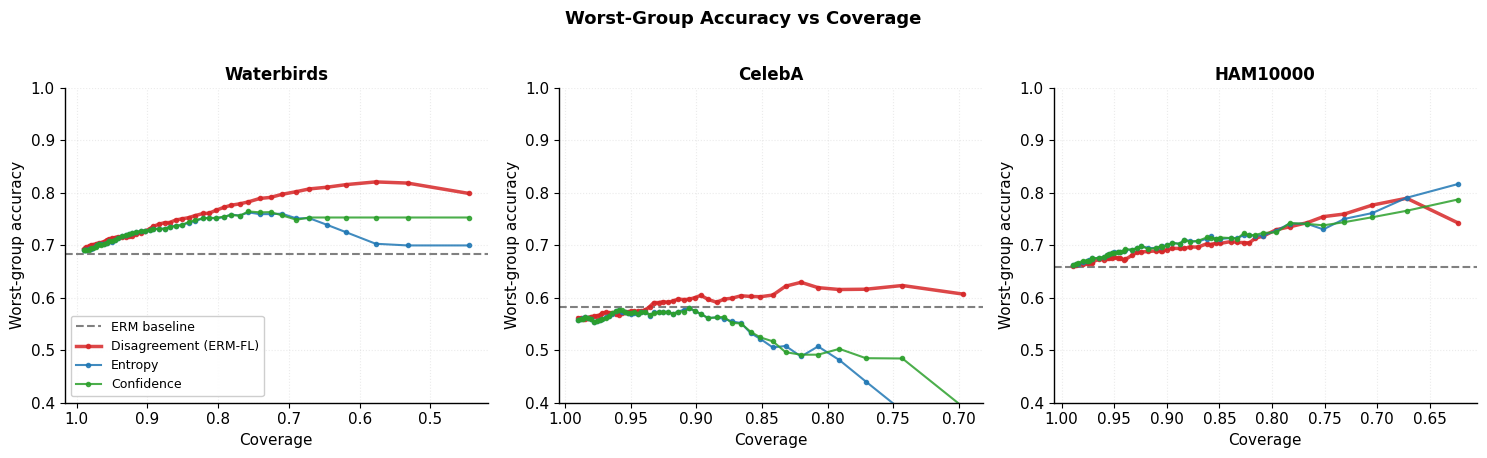


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Figure 4 — Error on Agreement vs Disagreement
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.png


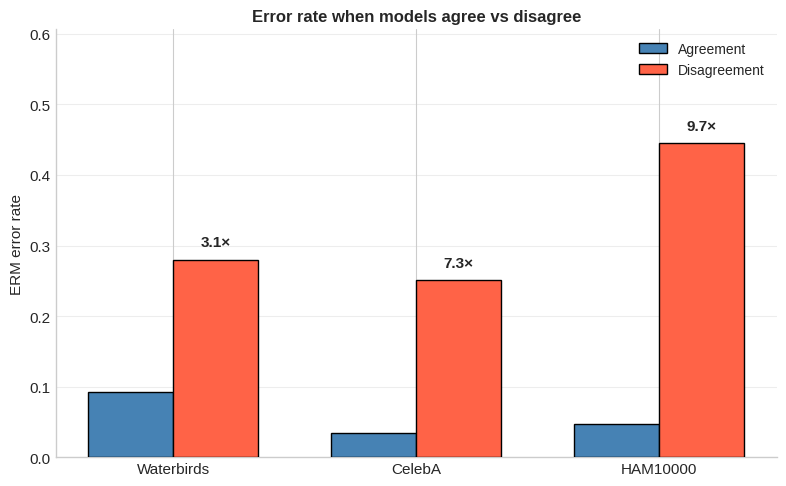


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Group Correlation Plot
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Correlation (ERM error vs disagreement): 0.890
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.png


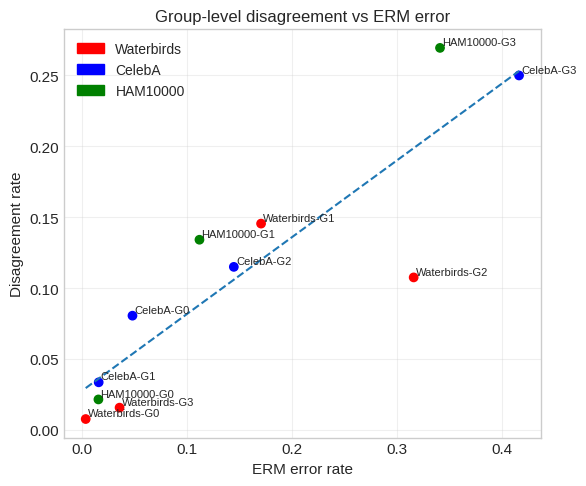


════════════════════════════════════════════════════════════
  ✓  All tables printed above.
  ✓  Figures saved to: /content/drive/MyDrive/TDL/paper_outputs
════════════════════════════════════════════════════════════


In [ ]:
"""
paper_results.py
════════════════════════════════════════════════════════════════════════════
Single script producing all tables and figures for the IntelliSys paper.

Tables:
  Table 1 — Coverage-Matched WGA          (main result)
  Table 2 — Complementarity Ablation      (ERM-FL vs ERM-ERM, both n=3)
  Table 3 — Error-Detection AUC
  Table 4 — Error Concentration on Disagreement

Figures (saved as PDF + PNG to OUTPUT_DIR):
  Figure 1 — WGA vs Coverage curves
  Figure 4 — Error rate: Agreement vs Disagreement

Changes from previous version:
  [Fix 1] Threshold grids are now computed per score (disagreement / entropy /
          confidence each use their own quantile-derived grid), eliminating
          artificial truncation of entropy and confidence sweeps.
  [Fix 2] Figure 1 now averages WGA curves across all 3 seeds rather than
          using seed 0 only, making the figure consistent with Table 1.
  [Fix 3] sweep_dis / sweep_ent / sweep_conf stored in all_results now use
          their respective per-score threshold grids (cleanliness; these
          sweeps are not used by the fixed figure but may be inspected).

Usage in Colab:
  1. Run this script — it mounts Google Drive automatically.
  2. Edit the SEEDS block with your actual CSV paths.
  3. Run: !python paper_results.py
     (or paste into a cell and execute)
"""

# # ── Mount Google Drive (Colab only) ──────────────────────────────────────
# try:
#     from google.colab import drive
#     drive.mount("/content/drive", force_remount=False)
#     print("Google Drive mounted.")
# except ImportError:
#     print("Not in Colab — skipping Drive mount.")

# ── Imports ───────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
})

# ════════════════════════════════════════════════════════════════════════════
#  ①  CONFIGURATION — Edit this block only
# ════════════════════════════════════════════════════════════════════════════

SEEDS = {
    "Waterbirds": {
        # erm_fl: list of (erm_csv, fl_csv) — one tuple per FL seed (42, 123, 456)
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_456.csv",
            ),
        ],
        # erm_erm: 3 pairs of independent ERM seeds — matched n=3 to ERM-FL
        # Pairs: (seed42,seed123), (seed123,seed456), (seed42,seed456)
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "CelebA": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "HAM10000": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
        ],
    },
}

# Minimum coverage constraint for threshold selection
MIN_COVERAGE = 0.50

# Grid resolution for threshold sweeps
N_THRESHOLDS = 50

# Output directory for figures (on Drive so they survive runtime resets)
OUTPUT_DIR = "/content/drive/MyDrive/TDL/paper_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
#  ②  CORE EVAL FUNCTIONS  (self-contained; no external eval.py needed)
# ════════════════════════════════════════════════════════════════════════════

def _normalize_fl_columns(fl_df):
    """Accept FL CSVs with either 'prediction'/'confidence' or 'fl_prediction'/'fl_confidence'."""
    fl = fl_df.copy()
    if "prediction" not in fl.columns and "fl_prediction" in fl.columns:
        fl = fl.rename(columns={"fl_prediction": "prediction"})
    if "confidence" not in fl.columns and "fl_confidence" in fl.columns:
        fl = fl.rename(columns={"fl_confidence": "confidence"})
    missing = [c for c in ["image_id", "prediction", "confidence"] if c not in fl.columns]
    if missing:
        raise ValueError(f"FL CSV missing columns: {missing}")
    return fl[["image_id", "prediction", "confidence"]]


def load_and_merge(erm_csv, fl_csv):
    """Merge ERM and FL prediction CSVs on image_id."""
    erm = pd.read_csv(erm_csv)
    fl  = pd.read_csv(fl_csv)
    fl  = _normalize_fl_columns(fl)

    df = erm.merge(fl, on="image_id", how="inner", suffixes=("_x", "_y"))

    renames = {}
    for col in df.columns:
        if col == "prediction_x":   renames[col] = "erm_prediction"
        elif col == "prediction_y": renames[col] = "fl_prediction"
        elif col == "confidence_x": renames[col] = "erm_confidence"
        elif col == "confidence_y": renames[col] = "fl_confidence"
    df = df.rename(columns=renames)

    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Merged frame missing columns: {missing}. Available: {list(df.columns)}")
    return df


def load_and_merge_erm_erm(erm1_csv, erm2_csv):
    """
    Load two independent ERM CSVs.
    Model 1 is treated as 'ERM' (primary model whose errors we predict).
    Model 2 plays the structural 'FL' role for disagreement scoring.
    """
    erm1 = pd.read_csv(erm1_csv)
    erm2 = pd.read_csv(erm2_csv)[["image_id", "prediction", "confidence"]].rename(
        columns={"prediction": "fl_prediction", "confidence": "fl_confidence"}
    )
    df = erm1.merge(erm2, on="image_id", how="inner").rename(
        columns={"prediction": "erm_prediction", "confidence": "erm_confidence"}
    )
    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"ERM-ERM merge missing columns: {missing}")
    return df


def add_scores(df):
    """Add disagreement, entropy, and confidence scores to a merged DataFrame."""
    out = df.copy()
    eps = 1e-12
    p = out["erm_confidence"].clip(eps, 1 - eps)
    out["score_disagreement"] = (out["erm_confidence"] - out["fl_confidence"]).abs()
    out["score_entropy"]      = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    out["score_confidence"]   = 1 - out["erm_confidence"]
    out["error"]              = (out["erm_prediction"] != out["label"]).astype(int)
    return out


def compute_wga(df):
    """Worst-group accuracy of the ERM model on df."""
    return float((df["erm_prediction"] == df["label"]).groupby(df["group"]).mean().min())


def eval_abstention(df, score_col, thresholds):
    """Sweep thresholds; return DataFrame of (threshold, coverage, wga)."""
    expected_groups = set(df["group"].unique())
    records = []
    for t in thresholds:
        retained = df[df[score_col] <= t]
        coverage = len(retained) / len(df)
        if retained.empty or set(retained["group"].unique()) != expected_groups:
            wga = np.nan
        else:
            wga = compute_wga(retained)
        records.append({"threshold": float(t), "coverage": float(coverage), "wga": wga})
    return pd.DataFrame(records)


def select_best_tau(results_df, min_coverage=0.5):
    """Return threshold that maximises WGA subject to coverage >= min_coverage."""
    valid = results_df.dropna(subset=["wga"])
    valid = valid[valid["coverage"] >= min_coverage]
    if valid.empty:
        raise ValueError("No valid threshold satisfies the coverage constraint.")
    return float(valid.loc[valid["wga"].idxmax(), "threshold"])


def coverage_matched_wga(df, target_cov, score_col, n_thr=200):
    """Find WGA at the threshold whose coverage is closest to target_cov."""
    thr = np.linspace(0, float(df[score_col].quantile(0.995)), n_thr)
    expected_groups = set(df["group"].unique())
    best_wga = best_cov = best_tau = np.nan
    best_diff = np.inf
    for t in thr:
        retained = df[df[score_col] <= t]
        cov = len(retained) / len(df)
        diff = abs(cov - target_cov)
        if diff < best_diff and not retained.empty \
                and set(retained["group"].unique()) == expected_groups:
            best_diff, best_wga, best_cov, best_tau = diff, compute_wga(retained), cov, float(t)
    return best_wga, best_cov, best_tau


def compute_auc(df):
    """AUROC for predicting ERM errors with each uncertainty score."""
    y = df["error"]
    if y.nunique() < 2:
        return {"disagreement": np.nan, "entropy": np.nan, "confidence": np.nan}
    return {
        "disagreement": roc_auc_score(y, df["score_disagreement"]),
        "entropy":      roc_auc_score(y, df["score_entropy"]),
        "confidence":   roc_auc_score(y, df["score_confidence"]),
    }


def compute_group_stats(df):
    """Per-group: ERM acc, FL acc, disagreement rate, post-abstention acc."""
    results = []
    # [Fix 1] Use per-score threshold grid for disagreement
    thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
    res = eval_abstention(df, "score_disagreement", thr)
    tau = select_best_tau(res, MIN_COVERAGE)

    for g in sorted(df["group"].unique()):
        gdf = df[df["group"] == g]
        erm_acc  = (gdf["erm_prediction"] == gdf["label"]).mean()
        fl_acc   = (gdf["fl_prediction"]  == gdf["label"]).mean()
        disagree = (gdf["erm_prediction"] != gdf["fl_prediction"]).mean()
        retained = gdf[gdf["score_disagreement"] <= tau]
        post_acc = (retained["erm_prediction"] == retained["label"]).mean() \
            if len(retained) > 0 else np.nan
        results.append({"group": g, "erm_acc": erm_acc, "fl_acc": fl_acc,
                        "disagree_rate": disagree, "post_acc": post_acc})
    return pd.DataFrame(results)


def compute_error_concentration(erm_csv, fl_csv):
    """P(ERM error | agree) vs P(ERM error | disagree) and their ratio."""
    df = load_and_merge(erm_csv, fl_csv)
    df["agree"] = df["erm_prediction"] == df["fl_prediction"]
    df["error"] = df["erm_prediction"] != df["label"]
    n_a, n_d = df["agree"].sum(), (~df["agree"]).sum()
    err_a = float((df["error"] & df["agree"]).sum()  / n_a) if n_a > 0 else np.nan
    err_d = float((df["error"] & ~df["agree"]).sum() / n_d) if n_d > 0 else np.nan
    ratio = err_d / err_a if (err_a and err_a > 0) else np.nan
    return {"err_agree": err_a, "err_disagree": err_d, "ratio": ratio}


# ── Formatting helpers ─────────────────────────────────────────────────────

def ms(vals):
    """'mean ± std' string, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}" if v else "N/A"

def mo(vals):
    """Mean only, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan


# ════════════════════════════════════════════════════════════════════════════
#  ③  MAIN AGGREGATION LOOP
# ════════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())
all_results = {}

for dataset in DATASETS:
    print(f"\n{'━'*60}")
    print(f"  Processing: {dataset}")
    print(f"{'━'*60}")

    b = {k: [] for k in [
        "erm_wga",
        "cm_wga_dis", "cm_cov_dis",
        "cm_wga_ent",  "cm_cov_ent",
        "cm_wga_conf", "cm_cov_conf",
        "auc_dis", "auc_ent", "auc_conf",
        "err_agree", "err_disagree", "err_ratio",
        # ERM-ERM ablation — now n=3 pairs, stored as lists (same as ERM-FL)
        "erm_erm_best_wga", "erm_erm_auc_dis",
    ]}
    # [Fix 3] sweep_* are now stored per-seed as lists; Figure 1 averages them
    b["sweep_dis"]  = []
    b["sweep_ent"]  = []
    b["sweep_conf"] = []

    # ── ERM-FL seeds ──────────────────────────────────────────────────────
    for i, (erm_csv, fl_csv) in enumerate(SEEDS[dataset]["erm_fl"]):
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP ERM-FL seed {i}] file not found:\n    {erm_csv}\n    {fl_csv}")
            continue
        print(f"  ERM-FL seed {i} … ", end="", flush=True)

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        # [Fix 1] Compute a separate threshold grid per score so that each
        # score's sweep covers its own full range and is not artificially
        # truncated by the disagreement score's (typically smaller) quantile.
        thr_dis  = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        thr_ent  = np.linspace(0, float(df["score_entropy"].quantile(0.99)),      N_THRESHOLDS)
        thr_conf = np.linspace(0, float(df["score_confidence"].quantile(0.99)),   N_THRESHOLDS)

        if not b["erm_wga"]:
            b["erm_wga"].append(compute_wga(df))

        aucs = compute_auc(df)
        b["auc_dis"].append(aucs["disagreement"])
        b["auc_ent"].append(aucs["entropy"])
        b["auc_conf"].append(aucs["confidence"])

        ec = compute_error_concentration(erm_csv, fl_csv)
        b["err_agree"].append(ec["err_agree"])
        b["err_disagree"].append(ec["err_disagree"])
        b["err_ratio"].append(ec["ratio"])

        res_dis = eval_abstention(df, "score_disagreement", thr_dis)
        try:
            tau_dis    = select_best_tau(res_dis, MIN_COVERAGE)
            target_cov = float(res_dis.loc[
                np.isclose(res_dis["threshold"], tau_dis), "coverage"
            ].iloc[0])
            best_dis_row = res_dis[np.isclose(res_dis["threshold"], tau_dis)].iloc[0]
            b["cm_wga_dis"].append(float(best_dis_row["wga"]))
            b["cm_cov_dis"].append(target_cov)
            wga_ent,  cov_ent,  _ = coverage_matched_wga(df, target_cov, "score_entropy")
            wga_conf, cov_conf, _ = coverage_matched_wga(df, target_cov, "score_confidence")
            b["cm_wga_ent"].append(wga_ent);   b["cm_cov_ent"].append(cov_ent)
            b["cm_wga_conf"].append(wga_conf); b["cm_cov_conf"].append(cov_conf)
        except ValueError as e:
            print(f"\n  [WARN seed {i}] {e}")
            for key in ["cm_wga_dis","cm_cov_dis","cm_wga_ent",
                        "cm_cov_ent","cm_wga_conf","cm_cov_conf"]:
                b[key].append(np.nan)

        # [Fix 1 + Fix 3] Store per-seed sweeps using per-score grids.
        # Figure 1 will average across these rather than using seed 0 only.
        b["sweep_dis"].append(eval_abstention(df, "score_disagreement", thr_dis))
        b["sweep_ent"].append(eval_abstention(df, "score_entropy",      thr_ent))
        b["sweep_conf"].append(eval_abstention(df, "score_confidence",  thr_conf))

        print("done")

    # ── ERM-ERM ablation — 3 pairs, matched n=3 ──────────────────────────
    print(f"  ERM-ERM pairs … ", end="", flush=True)
    for pair_idx, (erm1_csv, erm2_csv) in enumerate(SEEDS[dataset]["erm_erm"]):
        if not (os.path.exists(erm1_csv) and os.path.exists(erm2_csv)):
            print(f"\n  [SKIP ERM-ERM pair {pair_idx}] file not found:\n    {erm1_csv}\n    {erm2_csv}")
            b["erm_erm_best_wga"].append(np.nan)
            b["erm_erm_auc_dis"].append(np.nan)
            continue

        df_ee   = add_scores(load_and_merge_erm_erm(erm1_csv, erm2_csv))
        aucs_ee = compute_auc(df_ee)
        b["erm_erm_auc_dis"].append(aucs_ee["disagreement"])

        # [Fix 1] Use per-score grid for ERM-ERM disagreement sweep too
        thr_ee = np.linspace(0, float(df_ee["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        res_ee = eval_abstention(df_ee, "score_disagreement", thr_ee)
        valid  = res_ee.dropna(subset=["wga"])
        valid  = valid[valid["coverage"] >= MIN_COVERAGE]
        best   = float(valid.loc[valid["wga"].idxmax(), "wga"]) if not valid.empty else np.nan
        b["erm_erm_best_wga"].append(best)
        print(f"pair {pair_idx} done … ", end="", flush=True)
    print()

    # ── Per-group table ───────────────────────────────────────────────────
    print(f"\n  Per-group analysis — {dataset}")
    print("  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc")
    erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
    if os.path.exists(erm_csv) and os.path.exists(fl_csv):
        df = add_scores(load_and_merge(erm_csv, fl_csv))
        for _, row in compute_group_stats(df).iterrows():
            print(
                f"  G{int(row['group'])} | "
                f"{row['erm_acc']*100:6.1f}% | {row['fl_acc']*100:6.1f}% | "
                f"{row['disagree_rate']*100:6.1f}% | {row['post_acc']*100:6.1f}%"
            )

    all_results[dataset] = b


# ════════════════════════════════════════════════════════════════════════════
#  ④  PRINT TABLES
# ════════════════════════════════════════════════════════════════════════════

BAR = "═" * 92

# ── Table 1 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 1 — Coverage-Matched Worst-Group Accuracy (mean ± std, n=3)")
print("  Entropy and Confidence evaluated at the same coverage as Disagreement's best τ.")
print(BAR)
print(f"{'Dataset':<12}  {'ERM Baseline':>14}  {'Dis WGA':>18}  {'Cov':>7}  {'Ent WGA':>18}  {'Conf WGA':>18}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['erm_wga']):>14}  "
        f"{ms(b['cm_wga_dis']):>18}  {ms(b['cm_cov_dis']):>7}  "
        f"{ms(b['cm_wga_ent']):>18}  {ms(b['cm_wga_conf']):>18}"
    )

# ── Table 2 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 2 — Complementarity Ablation: ERM-FL vs ERM-ERM Disagreement")
print("  Both conditions: mean ± std over n=3 pairs.")
print("  ERM-FL:  (seed42,seed42), (seed42,seed123), (seed42,seed456)")
print("  ERM-ERM: (seed42,seed123), (seed123,seed456), (seed42,seed456)")
print(BAR)
print(f"{'Dataset':<12}  {'Metric':<16}  {'ERM-FL (n=3)':>22}  {'ERM-ERM (n=3)':>22}  {'Δ (FL−ERM)':>12}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    fl_wga = mo(b["cm_wga_dis"]);  ee_wga = mo(b["erm_erm_best_wga"])
    fl_auc = mo(b["auc_dis"]);     ee_auc = mo(b["erm_erm_auc_dis"])
    dw = f"{fl_wga - ee_wga:+.4f}" if not (np.isnan(fl_wga) or np.isnan(ee_wga)) else "N/A"
    da = f"{fl_auc - ee_auc:+.4f}" if not (np.isnan(fl_auc) or np.isnan(ee_auc)) else "N/A"
    print(f"{d:<12}  {'Best WGA':<16}  {ms(b['cm_wga_dis']):>22}  {ms(b['erm_erm_best_wga']):>22}  {dw:>12}")
    print(f"{d:<12}  {'Error-Det AUC':<16}  {ms(b['auc_dis']):>22}  {ms(b['erm_erm_auc_dis']):>22}  {da:>12}")
    print()

# ── Table 3 ───────────────────────────────────────────────────────────────
print(f"\n{BAR}")
print("  TABLE 3 — Error-Detection AUC / AUROC (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Disagreement':>20}  {'Entropy':>20}  {'Confidence':>20}")
print("-" * 76)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['auc_dis']):>20}  {ms(b['auc_ent']):>20}  {ms(b['auc_conf']):>20}")

# ── Table 4 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 4 — Error Concentration: Agreement vs Disagreement (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Err | Agree':>18}  {'Err | Disagree':>18}  {'Ratio (×)':>12}")
print("-" * 64)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['err_agree']):>18}  {ms(b['err_disagree']):>18}  {ms(b['err_ratio']):>12}")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  SUMMARY — WGA gain (Disagreement vs ERM baseline) and Ablation gap")
print(BAR)
for d in DATASETS:
    b = all_results[d]
    erm = mo(b["erm_wga"]);  dis = mo(b["cm_wga_dis"])
    ee  = mo(b["erm_erm_best_wga"])
    delta_erm = dis - erm if not np.isnan(dis + erm) else np.nan
    delta_ee  = dis - ee  if not np.isnan(dis + ee)  else np.nan
    print(
        f"  {d:<12}  vs ERM baseline: Δ={delta_erm:+.4f} ({delta_erm*100:+.1f} pp)"
        f"  |  vs ERM-ERM: Δ={delta_ee:+.4f} ({delta_ee*100:+.1f} pp)"
    )


# ════════════════════════════════════════════════════════════════════════════
#  ⑤  FIGURE 1 — WGA vs Coverage
# ════════════════════════════════════════════════════════════════════════════

def _interpolate_wga_at_coverages(sweep_df, target_covs):
    """
    Given a sweep DataFrame (columns: coverage, wga) and a sorted array of
    target coverage values, return WGA interpolated at each target coverage.
    NaNs are dropped before interpolation.
    """
    data = sweep_df.dropna(subset=["wga"]).sort_values("coverage")
    if data.empty:
        return np.full(len(target_covs), np.nan)
    return np.interp(target_covs, data["coverage"].values, data["wga"].values,
                     left=np.nan, right=np.nan)


def generate_figure1(all_results, datasets, erm_wgas, seeds_cfg, output_dir):
    """
    [Fix 2] Figure 1 now averages WGA curves across all seeds for each method,
    making the plot consistent with the multi-seed averages reported in Table 1.

    For each dataset and each coverage level on the disagreement grid:
      - disagreement WGA  = mean of seed-specific disagreement sweeps
      - entropy WGA       = mean of coverage-matched entropy WGA across seeds
      - confidence WGA    = mean of coverage-matched confidence WGA across seeds

    This is the natural extension of the Table 1 coverage-matching logic to the
    full coverage range.
    """
    colors = {
        "disagreement": "#d62728",
        "entropy":      "#1f77b4",
        "confidence":   "#2ca02c",
    }
    labels = {
        "disagreement": "Disagreement (ERM-FL)",
        "entropy":      "Entropy",
        "confidence":   "Confidence",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, dataset in zip(axes, datasets):
        b = all_results[dataset]

        # ERM baseline
        ax.axhline(erm_wgas[dataset], color="grey", linestyle="--", linewidth=1.5,
                   label="ERM baseline", zorder=1)

        seed_pairs = seeds_cfg[dataset]["erm_fl"]
        n_seeds = len(b["sweep_dis"])

        if n_seeds == 0:
            ax.set_title(dataset, fontsize=12, fontweight="bold")
            continue

        # Build a common coverage grid from seed 0's disagreement sweep
        # (all seeds use the same test set so coverage grids are equivalent)
        ref_sweep = b["sweep_dis"][0].dropna(subset=["wga"]).sort_values("coverage")
        cov_grid  = ref_sweep["coverage"].values  # shape (N_THRESHOLDS,)

        # Collect per-seed WGA arrays for each method
        wga_dis_seeds  = []
        wga_ent_seeds  = []
        wga_conf_seeds = []

        for seed_idx, (erm_csv, fl_csv) in enumerate(seed_pairs):
            if seed_idx >= n_seeds:
                break
            if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
                continue

            df = add_scores(load_and_merge(erm_csv, fl_csv))

            # Disagreement: interpolate seed's own sweep onto the common grid
            wga_dis_seeds.append(
                _interpolate_wga_at_coverages(b["sweep_dis"][seed_idx], cov_grid)
            )

            # Entropy / confidence: coverage-matched at each point on the grid
            ent_vals  = []
            conf_vals = []
            for cov in cov_grid:
                wga_e, _, _ = coverage_matched_wga(df, cov, "score_entropy")
                wga_c, _, _ = coverage_matched_wga(df, cov, "score_confidence")
                ent_vals.append(wga_e)
                conf_vals.append(wga_c)
            wga_ent_seeds.append(np.array(ent_vals))
            wga_conf_seeds.append(np.array(conf_vals))

        if not wga_dis_seeds:
            ax.set_title(dataset, fontsize=12, fontweight="bold")
            continue

        # Average across seeds (nanmean so missing seeds don't break things)
        mean_dis  = np.nanmean(wga_dis_seeds,  axis=0)
        mean_ent  = np.nanmean(wga_ent_seeds,  axis=0)
        mean_conf = np.nanmean(wga_conf_seeds, axis=0)

        for method, mean_vals in [
            ("disagreement", mean_dis),
            ("entropy",      mean_ent),
            ("confidence",   mean_conf),
        ]:
            # Drop NaN entries before plotting
            mask = ~np.isnan(mean_vals)
            ax.plot(
                cov_grid[mask], mean_vals[mask],
                color=colors[method],
                linewidth=2.5 if method == "disagreement" else 1.5,
                label=labels[method],
                marker="o", markersize=3, alpha=0.85,
            )

        ax.set_xlabel("Coverage", fontsize=11)
        ax.set_ylabel("Worst-group accuracy", fontsize=11)
        ax.set_title(dataset, fontsize=12, fontweight="bold")
        ax.invert_xaxis()
        ax.set_ylim(0.4, 1.0)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(loc="lower left", fontsize=9, framealpha=0.95)
    plt.suptitle("Worst-Group Accuracy vs Coverage", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure1_wga_vs_coverage.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑥  FIGURE 4 — Error on Agreement vs Disagreement
# ════════════════════════════════════════════════════════════════════════════

def generate_figure4(all_results, datasets, output_dir):
    plt.style.use("seaborn-v0_8-whitegrid")
    err_agree    = [mo(all_results[d]["err_agree"])    for d in datasets]
    err_disagree = [mo(all_results[d]["err_disagree"]) for d in datasets]
    ratios       = [mo(all_results[d]["err_ratio"])    for d in datasets]
    x, width = np.arange(len(datasets)), 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, err_agree,    width, color="steelblue", edgecolor="black", label="Agreement",    zorder=3)
    bars = ax.bar(x + width/2, err_disagree, width, color="tomato",    edgecolor="black", label="Disagreement", zorder=3)
    for bar, ratio in zip(bars, ratios):
        if np.isfinite(ratio):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                    f"{ratio:.1f}×", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(datasets)
    ax.set_ylabel("ERM error rate", fontsize=11)
    ax.set_title("Error rate when models agree vs disagree", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(err_disagree) * 1.25 + 0.05)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_facecolor("white"); fig.patch.set_facecolor("white")
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure4_error_disagreement.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑦  GROUP CORRELATION PLOT
# ════════════════════════════════════════════════════════════════════════════

def generate_group_correlation_plot(SEEDS, output_dir):
    xs, ys, labels, colors = [], [], [], []

    dataset_colors = {
        "Waterbirds": "red",
        "CelebA":     "blue",
        "HAM10000":   "green",
    }

    for dataset in SEEDS:
        erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        for g in sorted(df["group"].unique()):
            gdf = df[df["group"] == g]
            xs.append(1 - (gdf["erm_prediction"] == gdf["label"]).mean())
            ys.append((gdf["erm_prediction"] != gdf["fl_prediction"]).mean())
            labels.append(f"{dataset}-G{g}")
            colors.append(dataset_colors.get(dataset, "black"))

    plt.figure(figsize=(6, 5))
    plt.scatter(xs, ys, c=colors)

    for x, y, label in zip(xs, ys, labels):
        plt.text(x + 0.002, y + 0.002, label, fontsize=8)

    if len(xs) > 1:
        coef   = np.polyfit(xs, ys, 1)
        x_line = np.linspace(min(xs), max(xs), 100)
        plt.plot(x_line, coef[0] * x_line + coef[1], linestyle="--")
        print(f"  Correlation (ERM error vs disagreement): {np.corrcoef(xs, ys)[0,1]:.3f}")

    plt.xlabel("ERM error rate")
    plt.ylabel("Disagreement rate")
    plt.title("Group-level disagreement vs ERM error")
    plt.grid(True, alpha=0.3)

    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(color="red",   label="Waterbirds"),
        mpatches.Patch(color="blue",  label="CelebA"),
        mpatches.Patch(color="green", label="HAM10000"),
    ]
    plt.legend(handles=legend_handles)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"group_disagreement_correlation.{ext}")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close()


# ════════════════════════════════════════════════════════════════════════════
#  ⑧  GENERATE FIGURES
# ════════════════════════════════════════════════════════════════════════════

erm_wga_dict = {d: mo(all_results[d]["erm_wga"]) for d in DATASETS}

print(f"\n\n{'━'*60}")
print("  Generating Figure 1 — WGA vs Coverage")
print(f"{'━'*60}")
# [Fix 2] Pass SEEDS so generate_figure1 can load all seeds for averaging
generate_figure1(all_results, DATASETS, erm_wga_dict, SEEDS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Figure 4 — Error on Agreement vs Disagreement")
print(f"{'━'*60}")
generate_figure4(all_results, DATASETS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Group Correlation Plot")
print(f"{'━'*60}")
generate_group_correlation_plot(SEEDS, OUTPUT_DIR)

print(f"\n{'═'*60}")
print("  ✓  All tables printed above.")
print(f"  ✓  Figures saved to: {OUTPUT_DIR}")
print(f"{'═'*60}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: Waterbirds
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — Waterbirds
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   99.6% |   99.4% |    0.8% |   99.9%
  G1 |   82.9% |   71.6% |   14.5% |   84.6%
  G2 |   68.4% |   74.1% |   10.7% |   85.4%
  G3 |   96.4% |   97.0% |    1.6% |   99.6%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Processing: CelebA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ERM-FL seed 0 … done
  ERM-FL seed 1 … done
  ERM-FL seed 2 … done
  ERM-ERM pairs … pair 0 done … pair 1 done … pair 2 done … 

  Per-group analysis — CelebA
  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc
  G0 |   95.2% |   88.4% |    8.0% |   98.7%
  G1 |   98.4% |   96.4% |    3.3% |   99.9

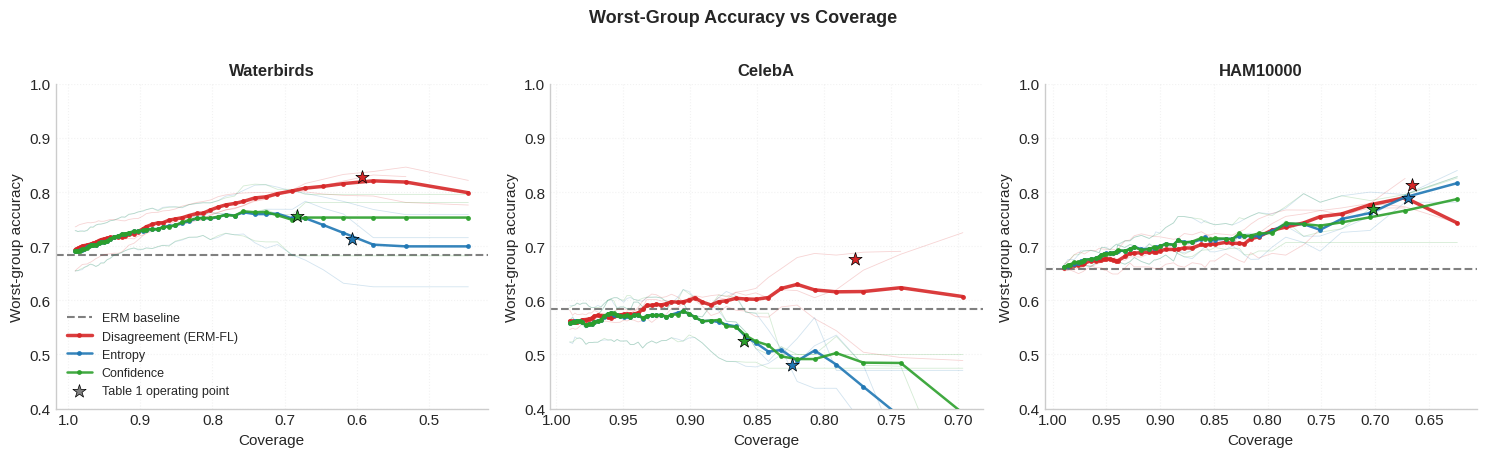


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Figure 4 — Error on Agreement vs Disagreement
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/figure4_error_disagreement.png


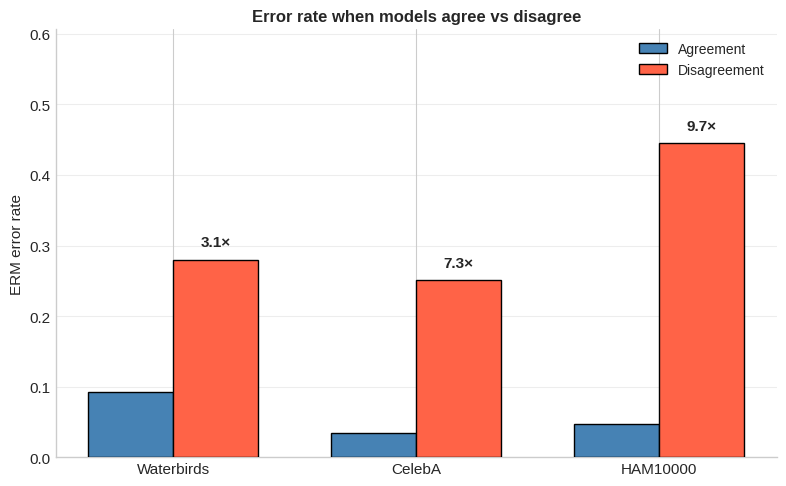


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Generating Group Correlation Plot
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Correlation (ERM error vs disagreement): 0.890
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.pdf
  Saved /content/drive/MyDrive/TDL/paper_outputs/group_disagreement_correlation.png


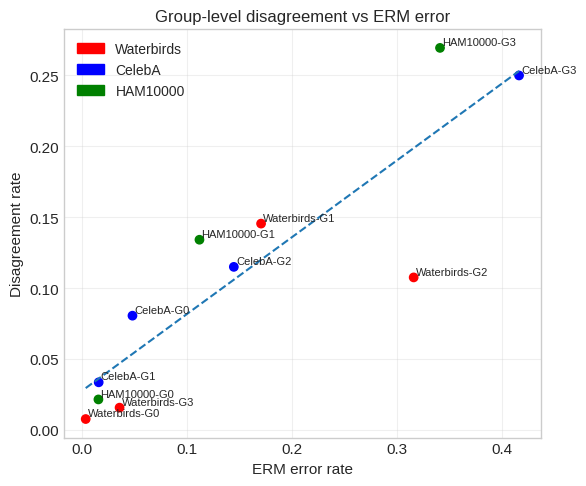


════════════════════════════════════════════════════════════
  ✓  All tables printed above.
  ✓  Figures saved to: /content/drive/MyDrive/TDL/paper_outputs
════════════════════════════════════════════════════════════


In [ ]:
"""
paper_results.py
════════════════════════════════════════════════════════════════════════════
Single script producing all tables and figures for the IntelliSys paper.

Tables:
  Table 1 — Coverage-Matched WGA          (main result)
  Table 2 — Complementarity Ablation      (ERM-FL vs ERM-ERM, both n=3)
  Table 3 — Error-Detection AUC
  Table 4 — Error Concentration on Disagreement

Figures (saved as PDF + PNG to OUTPUT_DIR):
  Figure 1 — WGA vs Coverage curves
  Figure 4 — Error rate: Agreement vs Disagreement

Changes from previous version:
  [Fix 1] Threshold grids are now computed per score (disagreement / entropy /
          confidence each use their own quantile-derived grid), eliminating
          artificial truncation of entropy and confidence sweeps.
  [Fix 2] Figure 1 plots faint per-seed curves for each method, overlaid with
          a mean curve, and marks the Table 1 operating point (mean coverage,
          mean WGA) as a filled star on each method's mean curve. This resolves
          the Jensen-type mismatch between mean(best per seed) in Table 1 and
          best(mean curve) in the figure, making both representations visible.
  [Fix 3] sweep_dis / sweep_ent / sweep_conf stored in all_results now use
          their respective per-score threshold grids.

Usage in Colab:
  1. Run this script — it mounts Google Drive automatically.
  2. Edit the SEEDS block with your actual CSV paths.
  3. Run: !python paper_results.py
     (or paste into a cell and execute)
"""

# # ── Mount Google Drive (Colab only) ──────────────────────────────────────
# try:
#     from google.colab import drive
#     drive.mount("/content/drive", force_remount=False)
#     print("Google Drive mounted.")
# except ImportError:
#     print("Not in Colab — skipping Drive mount.")

# ── Imports ───────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
})

# ════════════════════════════════════════════════════════════════════════════
#  ①  CONFIGURATION — Edit this block only
# ════════════════════════════════════════════════════════════════════════════

SEEDS = {
    "Waterbirds": {
        # erm_fl: list of (erm_csv, fl_csv) — one tuple per FL seed (42, 123, 456)
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/free_lunch_test_predictions_456.csv",
            ),
        ],
        # erm_erm: 3 pairs of independent ERM seeds — matched n=3 to ERM-FL
        # Pairs: (seed42,seed123), (seed123,seed456), (seed42,seed456)
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/Waterbirds/erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "CelebA": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/CelebA/celeba_erm_test_predictions_seed456.csv",
            ),
        ],
    },
    "HAM10000": {
        "erm_fl": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_fl_test_predictions_456.csv",
            ),
        ],
        "erm_erm": [
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed123.csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
            (
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions (1).csv",
                "/content/drive/MyDrive/TDL/Final models and inference/HAM/new/day 1/ham_erm_test_predictions_seed456.csv",
            ),
        ],
    },
}

# Minimum coverage constraint for threshold selection
MIN_COVERAGE = 0.50

# Grid resolution for threshold sweeps
N_THRESHOLDS = 50

# Output directory for figures (on Drive so they survive runtime resets)
OUTPUT_DIR = "/content/drive/MyDrive/TDL/paper_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════
#  ②  CORE EVAL FUNCTIONS  (self-contained; no external eval.py needed)
# ════════════════════════════════════════════════════════════════════════════

def _normalize_fl_columns(fl_df):
    """Accept FL CSVs with either 'prediction'/'confidence' or 'fl_prediction'/'fl_confidence'."""
    fl = fl_df.copy()
    if "prediction" not in fl.columns and "fl_prediction" in fl.columns:
        fl = fl.rename(columns={"fl_prediction": "prediction"})
    if "confidence" not in fl.columns and "fl_confidence" in fl.columns:
        fl = fl.rename(columns={"fl_confidence": "confidence"})
    missing = [c for c in ["image_id", "prediction", "confidence"] if c not in fl.columns]
    if missing:
        raise ValueError(f"FL CSV missing columns: {missing}")
    return fl[["image_id", "prediction", "confidence"]]


def load_and_merge(erm_csv, fl_csv):
    """Merge ERM and FL prediction CSVs on image_id."""
    erm = pd.read_csv(erm_csv)
    fl  = pd.read_csv(fl_csv)
    fl  = _normalize_fl_columns(fl)

    df = erm.merge(fl, on="image_id", how="inner", suffixes=("_x", "_y"))

    renames = {}
    for col in df.columns:
        if col == "prediction_x":   renames[col] = "erm_prediction"
        elif col == "prediction_y": renames[col] = "fl_prediction"
        elif col == "confidence_x": renames[col] = "erm_confidence"
        elif col == "confidence_y": renames[col] = "fl_confidence"
    df = df.rename(columns=renames)

    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Merged frame missing columns: {missing}. Available: {list(df.columns)}")
    return df


def load_and_merge_erm_erm(erm1_csv, erm2_csv):
    """
    Load two independent ERM CSVs.
    Model 1 is treated as 'ERM' (primary model whose errors we predict).
    Model 2 plays the structural 'FL' role for disagreement scoring.
    """
    erm1 = pd.read_csv(erm1_csv)
    erm2 = pd.read_csv(erm2_csv)[["image_id", "prediction", "confidence"]].rename(
        columns={"prediction": "fl_prediction", "confidence": "fl_confidence"}
    )
    df = erm1.merge(erm2, on="image_id", how="inner").rename(
        columns={"prediction": "erm_prediction", "confidence": "erm_confidence"}
    )
    required = ["erm_prediction", "fl_prediction", "erm_confidence", "fl_confidence", "label", "group"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"ERM-ERM merge missing columns: {missing}")
    return df


def add_scores(df):
    """Add disagreement, entropy, and confidence scores to a merged DataFrame."""
    out = df.copy()
    eps = 1e-12
    p = out["erm_confidence"].clip(eps, 1 - eps)
    out["score_disagreement"] = (out["erm_confidence"] - out["fl_confidence"]).abs()
    out["score_entropy"]      = -(p * np.log(p) + (1 - p) * np.log(1 - p))
    out["score_confidence"]   = 1 - out["erm_confidence"]
    out["error"]              = (out["erm_prediction"] != out["label"]).astype(int)
    return out


def compute_wga(df):
    """Worst-group accuracy of the ERM model on df."""
    return float((df["erm_prediction"] == df["label"]).groupby(df["group"]).mean().min())


def eval_abstention(df, score_col, thresholds):
    """Sweep thresholds; return DataFrame of (threshold, coverage, wga)."""
    expected_groups = set(df["group"].unique())
    records = []
    for t in thresholds:
        retained = df[df[score_col] <= t]
        coverage = len(retained) / len(df)
        if retained.empty or set(retained["group"].unique()) != expected_groups:
            wga = np.nan
        else:
            wga = compute_wga(retained)
        records.append({"threshold": float(t), "coverage": float(coverage), "wga": wga})
    return pd.DataFrame(records)


def select_best_tau(results_df, min_coverage=0.5):
    """Return threshold that maximises WGA subject to coverage >= min_coverage."""
    valid = results_df.dropna(subset=["wga"])
    valid = valid[valid["coverage"] >= min_coverage]
    if valid.empty:
        raise ValueError("No valid threshold satisfies the coverage constraint.")
    return float(valid.loc[valid["wga"].idxmax(), "threshold"])


def coverage_matched_wga(df, target_cov, score_col, n_thr=200):
    """Find WGA at the threshold whose coverage is closest to target_cov."""
    thr = np.linspace(0, float(df[score_col].quantile(0.995)), n_thr)
    expected_groups = set(df["group"].unique())
    best_wga = best_cov = best_tau = np.nan
    best_diff = np.inf
    for t in thr:
        retained = df[df[score_col] <= t]
        cov = len(retained) / len(df)
        diff = abs(cov - target_cov)
        if diff < best_diff and not retained.empty \
                and set(retained["group"].unique()) == expected_groups:
            best_diff, best_wga, best_cov, best_tau = diff, compute_wga(retained), cov, float(t)
    return best_wga, best_cov, best_tau


def compute_auc(df):
    """AUROC for predicting ERM errors with each uncertainty score."""
    y = df["error"]
    if y.nunique() < 2:
        return {"disagreement": np.nan, "entropy": np.nan, "confidence": np.nan}
    return {
        "disagreement": roc_auc_score(y, df["score_disagreement"]),
        "entropy":      roc_auc_score(y, df["score_entropy"]),
        "confidence":   roc_auc_score(y, df["score_confidence"]),
    }


def compute_group_stats(df):
    """Per-group: ERM acc, FL acc, disagreement rate, post-abstention acc."""
    results = []
    # [Fix 1] Use per-score threshold grid for disagreement
    thr = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
    res = eval_abstention(df, "score_disagreement", thr)
    tau = select_best_tau(res, MIN_COVERAGE)

    for g in sorted(df["group"].unique()):
        gdf = df[df["group"] == g]
        erm_acc  = (gdf["erm_prediction"] == gdf["label"]).mean()
        fl_acc   = (gdf["fl_prediction"]  == gdf["label"]).mean()
        disagree = (gdf["erm_prediction"] != gdf["fl_prediction"]).mean()
        retained = gdf[gdf["score_disagreement"] <= tau]
        post_acc = (retained["erm_prediction"] == retained["label"]).mean() \
            if len(retained) > 0 else np.nan
        results.append({"group": g, "erm_acc": erm_acc, "fl_acc": fl_acc,
                        "disagree_rate": disagree, "post_acc": post_acc})
    return pd.DataFrame(results)


def compute_error_concentration(erm_csv, fl_csv):
    """P(ERM error | agree) vs P(ERM error | disagree) and their ratio."""
    df = load_and_merge(erm_csv, fl_csv)
    df["agree"] = df["erm_prediction"] == df["fl_prediction"]
    df["error"] = df["erm_prediction"] != df["label"]
    n_a, n_d = df["agree"].sum(), (~df["agree"]).sum()
    err_a = float((df["error"] & df["agree"]).sum()  / n_a) if n_a > 0 else np.nan
    err_d = float((df["error"] & ~df["agree"]).sum() / n_d) if n_d > 0 else np.nan
    ratio = err_d / err_a if (err_a and err_a > 0) else np.nan
    return {"err_agree": err_a, "err_disagree": err_d, "ratio": ratio}


# ── Formatting helpers ─────────────────────────────────────────────────────

def ms(vals):
    """'mean ± std' string, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return f"{np.mean(v):.4f} ± {np.std(v):.4f}" if v else "N/A"

def mo(vals):
    """Mean only, ignoring NaNs."""
    v = [x for x in vals if not np.isnan(x)]
    return np.mean(v) if v else np.nan


# ════════════════════════════════════════════════════════════════════════════
#  ③  MAIN AGGREGATION LOOP
# ════════════════════════════════════════════════════════════════════════════

DATASETS = list(SEEDS.keys())
all_results = {}

for dataset in DATASETS:
    print(f"\n{'━'*60}")
    print(f"  Processing: {dataset}")
    print(f"{'━'*60}")

    b = {k: [] for k in [
        "erm_wga",
        "cm_wga_dis", "cm_cov_dis",
        "cm_wga_ent",  "cm_cov_ent",
        "cm_wga_conf", "cm_cov_conf",
        "auc_dis", "auc_ent", "auc_conf",
        "err_agree", "err_disagree", "err_ratio",
        # ERM-ERM ablation — now n=3 pairs, stored as lists (same as ERM-FL)
        "erm_erm_best_wga", "erm_erm_auc_dis",
    ]}
    # [Fix 3] sweep_* stored as lists of per-seed DataFrames, one per seed,
    # each using its own per-score threshold grid.
    b["sweep_dis"]  = []
    b["sweep_ent"]  = []
    b["sweep_conf"] = []

    # ── ERM-FL seeds ──────────────────────────────────────────────────────
    for i, (erm_csv, fl_csv) in enumerate(SEEDS[dataset]["erm_fl"]):
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            print(f"  [SKIP ERM-FL seed {i}] file not found:\n    {erm_csv}\n    {fl_csv}")
            continue
        print(f"  ERM-FL seed {i} … ", end="", flush=True)

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        # [Fix 1] Separate threshold grid per score to avoid truncation.
        thr_dis  = np.linspace(0, float(df["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        thr_ent  = np.linspace(0, float(df["score_entropy"].quantile(0.99)),      N_THRESHOLDS)
        thr_conf = np.linspace(0, float(df["score_confidence"].quantile(0.99)),   N_THRESHOLDS)

        if not b["erm_wga"]:
            b["erm_wga"].append(compute_wga(df))

        aucs = compute_auc(df)
        b["auc_dis"].append(aucs["disagreement"])
        b["auc_ent"].append(aucs["entropy"])
        b["auc_conf"].append(aucs["confidence"])

        ec = compute_error_concentration(erm_csv, fl_csv)
        b["err_agree"].append(ec["err_agree"])
        b["err_disagree"].append(ec["err_disagree"])
        b["err_ratio"].append(ec["ratio"])

        res_dis = eval_abstention(df, "score_disagreement", thr_dis)
        try:
            tau_dis    = select_best_tau(res_dis, MIN_COVERAGE)
            target_cov = float(res_dis.loc[
                np.isclose(res_dis["threshold"], tau_dis), "coverage"
            ].iloc[0])
            best_dis_row = res_dis[np.isclose(res_dis["threshold"], tau_dis)].iloc[0]
            b["cm_wga_dis"].append(float(best_dis_row["wga"]))
            b["cm_cov_dis"].append(target_cov)
            wga_ent,  cov_ent,  _ = coverage_matched_wga(df, target_cov, "score_entropy")
            wga_conf, cov_conf, _ = coverage_matched_wga(df, target_cov, "score_confidence")
            b["cm_wga_ent"].append(wga_ent);   b["cm_cov_ent"].append(cov_ent)
            b["cm_wga_conf"].append(wga_conf); b["cm_cov_conf"].append(cov_conf)
        except ValueError as e:
            print(f"\n  [WARN seed {i}] {e}")
            for key in ["cm_wga_dis","cm_cov_dis","cm_wga_ent",
                        "cm_cov_ent","cm_wga_conf","cm_cov_conf"]:
                b[key].append(np.nan)

        # [Fix 1 + Fix 3] Per-seed sweeps with per-score grids.
        b["sweep_dis"].append(eval_abstention(df, "score_disagreement", thr_dis))
        b["sweep_ent"].append(eval_abstention(df, "score_entropy",      thr_ent))
        b["sweep_conf"].append(eval_abstention(df, "score_confidence",  thr_conf))

        print("done")

    # ── ERM-ERM ablation — 3 pairs, matched n=3 ──────────────────────────
    print(f"  ERM-ERM pairs … ", end="", flush=True)
    for pair_idx, (erm1_csv, erm2_csv) in enumerate(SEEDS[dataset]["erm_erm"]):
        if not (os.path.exists(erm1_csv) and os.path.exists(erm2_csv)):
            print(f"\n  [SKIP ERM-ERM pair {pair_idx}] file not found:\n    {erm1_csv}\n    {erm2_csv}")
            b["erm_erm_best_wga"].append(np.nan)
            b["erm_erm_auc_dis"].append(np.nan)
            continue

        df_ee   = add_scores(load_and_merge_erm_erm(erm1_csv, erm2_csv))
        aucs_ee = compute_auc(df_ee)
        b["erm_erm_auc_dis"].append(aucs_ee["disagreement"])

        # [Fix 1] Per-score grid for ERM-ERM disagreement
        thr_ee = np.linspace(0, float(df_ee["score_disagreement"].quantile(0.99)), N_THRESHOLDS)
        res_ee = eval_abstention(df_ee, "score_disagreement", thr_ee)
        valid  = res_ee.dropna(subset=["wga"])
        valid  = valid[valid["coverage"] >= MIN_COVERAGE]
        best   = float(valid.loc[valid["wga"].idxmax(), "wga"]) if not valid.empty else np.nan
        b["erm_erm_best_wga"].append(best)
        print(f"pair {pair_idx} done … ", end="", flush=True)
    print()

    # ── Per-group table ───────────────────────────────────────────────────
    print(f"\n  Per-group analysis — {dataset}")
    print("  Group | ERM Acc | FL Acc | Disagree | Post-Abstain Acc")
    erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
    if os.path.exists(erm_csv) and os.path.exists(fl_csv):
        df = add_scores(load_and_merge(erm_csv, fl_csv))
        for _, row in compute_group_stats(df).iterrows():
            print(
                f"  G{int(row['group'])} | "
                f"{row['erm_acc']*100:6.1f}% | {row['fl_acc']*100:6.1f}% | "
                f"{row['disagree_rate']*100:6.1f}% | {row['post_acc']*100:6.1f}%"
            )

    all_results[dataset] = b


# ════════════════════════════════════════════════════════════════════════════
#  ④  PRINT TABLES
# ════════════════════════════════════════════════════════════════════════════

BAR = "═" * 92

# ── Table 1 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 1 — Coverage-Matched Worst-Group Accuracy (mean ± std, n=3)")
print("  Entropy and Confidence evaluated at the same coverage as Disagreement's best τ.")
print(BAR)
print(f"{'Dataset':<12}  {'ERM Baseline':>14}  {'Dis WGA':>18}  {'Cov':>7}  {'Ent WGA':>18}  {'Conf WGA':>18}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    print(
        f"{d:<12}  {ms(b['erm_wga']):>14}  "
        f"{ms(b['cm_wga_dis']):>18}  {ms(b['cm_cov_dis']):>7}  "
        f"{ms(b['cm_wga_ent']):>18}  {ms(b['cm_wga_conf']):>18}"
    )

# ── Table 2 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 2 — Complementarity Ablation: ERM-FL vs ERM-ERM Disagreement")
print("  Both conditions: mean ± std over n=3 pairs.")
print("  ERM-FL:  (seed42,seed42), (seed42,seed123), (seed42,seed456)")
print("  ERM-ERM: (seed42,seed123), (seed123,seed456), (seed42,seed456)")
print(BAR)
print(f"{'Dataset':<12}  {'Metric':<16}  {'ERM-FL (n=3)':>22}  {'ERM-ERM (n=3)':>22}  {'Δ (FL−ERM)':>12}")
print("-" * 92)
for d in DATASETS:
    b = all_results[d]
    fl_wga = mo(b["cm_wga_dis"]);  ee_wga = mo(b["erm_erm_best_wga"])
    fl_auc = mo(b["auc_dis"]);     ee_auc = mo(b["erm_erm_auc_dis"])
    dw = f"{fl_wga - ee_wga:+.4f}" if not (np.isnan(fl_wga) or np.isnan(ee_wga)) else "N/A"
    da = f"{fl_auc - ee_auc:+.4f}" if not (np.isnan(fl_auc) or np.isnan(ee_auc)) else "N/A"
    print(f"{d:<12}  {'Best WGA':<16}  {ms(b['cm_wga_dis']):>22}  {ms(b['erm_erm_best_wga']):>22}  {dw:>12}")
    print(f"{d:<12}  {'Error-Det AUC':<16}  {ms(b['auc_dis']):>22}  {ms(b['erm_erm_auc_dis']):>22}  {da:>12}")
    print()

# ── Table 3 ───────────────────────────────────────────────────────────────
print(f"\n{BAR}")
print("  TABLE 3 — Error-Detection AUC / AUROC (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Disagreement':>20}  {'Entropy':>20}  {'Confidence':>20}")
print("-" * 76)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['auc_dis']):>20}  {ms(b['auc_ent']):>20}  {ms(b['auc_conf']):>20}")

# ── Table 4 ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  TABLE 4 — Error Concentration: Agreement vs Disagreement (mean ± std, n=3)")
print(BAR)
print(f"{'Dataset':<12}  {'Err | Agree':>18}  {'Err | Disagree':>18}  {'Ratio (×)':>12}")
print("-" * 64)
for d in DATASETS:
    b = all_results[d]
    print(f"{d:<12}  {ms(b['err_agree']):>18}  {ms(b['err_disagree']):>18}  {ms(b['err_ratio']):>12}")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n\n{BAR}")
print("  SUMMARY — WGA gain (Disagreement vs ERM baseline) and Ablation gap")
print(BAR)
for d in DATASETS:
    b = all_results[d]
    erm = mo(b["erm_wga"]);  dis = mo(b["cm_wga_dis"])
    ee  = mo(b["erm_erm_best_wga"])
    delta_erm = dis - erm if not np.isnan(dis + erm) else np.nan
    delta_ee  = dis - ee  if not np.isnan(dis + ee)  else np.nan
    print(
        f"  {d:<12}  vs ERM baseline: Δ={delta_erm:+.4f} ({delta_erm*100:+.1f} pp)"
        f"  |  vs ERM-ERM: Δ={delta_ee:+.4f} ({delta_ee*100:+.1f} pp)"
    )


# ════════════════════════════════════════════════════════════════════════════
#  ⑤  FIGURE 1 — WGA vs Coverage
# ════════════════════════════════════════════════════════════════════════════

def generate_figure1(all_results, datasets, erm_wgas, seeds_cfg, output_dir):
    """
    [Fix 2] Resolves the Jensen-type mismatch between Table 1 and the figure.

    Table 1 reports mean(best_per_seed): each seed selects its own optimal
    threshold, and results are averaged. A single mean curve cannot reproduce
    this because averaging before taking the max is not the same as taking the
    max then averaging.

    Solution (standard in ML papers):
      - Plot each seed's individual curve faintly to show run-to-run variance.
      - Overlay a bold mean curve per method.
      - Mark the Table 1 operating point (mean coverage, mean WGA) as a filled
        star on each method's mean curve. This star is exactly the number in
        the table, so figure and table are unambiguously linked.

    Coverage-matching for entropy / confidence:
      At every point on the disagreement coverage grid, entropy and confidence
      are evaluated at the same coverage via coverage_matched_wga, consistent
      with Table 1's methodology extended across the full range.
    """
    colors = {
        "disagreement": "#d62728",
        "entropy":      "#1f77b4",
        "confidence":   "#2ca02c",
    }
    labels = {
        "disagreement": "Disagreement (ERM-FL)",
        "entropy":      "Entropy",
        "confidence":   "Confidence",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    for ax, dataset in zip(axes, datasets):
        b          = all_results[dataset]
        seed_pairs = seeds_cfg[dataset]["erm_fl"]
        n_seeds    = len(b["sweep_dis"])

        # ERM baseline
        ax.axhline(
            erm_wgas[dataset], color="grey", linestyle="--",
            linewidth=1.5, label="ERM baseline", zorder=1,
        )

        if n_seeds == 0:
            ax.set_title(dataset, fontsize=12, fontweight="bold")
            continue

        # Common coverage grid from seed 0's disagreement sweep.
        # All seeds share the same test set so grids are aligned.
        ref_sweep = b["sweep_dis"][0].dropna(subset=["wga"]).sort_values("coverage")
        cov_grid  = ref_sweep["coverage"].values   # shape (N_THRESHOLDS,)

        # ── Collect per-seed WGA arrays aligned to cov_grid ───────────────
        per_seed = {m: [] for m in ("disagreement", "entropy", "confidence")}

        for seed_idx, (erm_csv, fl_csv) in enumerate(seed_pairs):
            if seed_idx >= n_seeds:
                break
            if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
                continue

            df = add_scores(load_and_merge(erm_csv, fl_csv))

            # Disagreement — interpolate this seed's sweep onto cov_grid
            seed_sweep = b["sweep_dis"][seed_idx].dropna(subset=["wga"]).sort_values("coverage")
            wga_dis = np.interp(
                cov_grid,
                seed_sweep["coverage"].values,
                seed_sweep["wga"].values,
                left=np.nan, right=np.nan,
            )
            per_seed["disagreement"].append(wga_dis)

            # Entropy / confidence — coverage-matched at each cov_grid point
            ent_vals, conf_vals = [], []
            for cov in cov_grid:
                wga_e, _, _ = coverage_matched_wga(df, cov, "score_entropy")
                wga_c, _, _ = coverage_matched_wga(df, cov, "score_confidence")
                ent_vals.append(wga_e)
                conf_vals.append(wga_c)
            per_seed["entropy"].append(np.array(ent_vals))
            per_seed["confidence"].append(np.array(conf_vals))

        if not per_seed["disagreement"]:
            ax.set_title(dataset, fontsize=12, fontweight="bold")
            continue

        # ── Plot faint per-seed curves then bold mean curve ────────────────
        for method in ("disagreement", "entropy", "confidence"):
            seed_arrays = per_seed[method]
            color       = colors[method]

            # Faint individual seed runs
            for arr in seed_arrays:
                mask = ~np.isnan(arr)
                ax.plot(
                    cov_grid[mask], arr[mask],
                    color=color, linewidth=0.6, alpha=0.20,
                    linestyle="-", zorder=2,
                )

            # Bold mean curve
            mean_arr = np.nanmean(seed_arrays, axis=0)
            mask     = ~np.isnan(mean_arr)
            ax.plot(
                cov_grid[mask], mean_arr[mask],
                color=color,
                linewidth=2.5 if method == "disagreement" else 1.8,
                label=labels[method],
                marker="o", markersize=2.5, alpha=0.9,
                zorder=3,
            )

        # ── Mark Table 1 operating points as filled stars ─────────────────
        # These are mean(best_per_seed) — exactly the Table 1 numbers.
        # Plotting them as stars bridges the Jensen gap visually: the star
        # sits slightly above the mean curve peak because it averages the per-
        # seed peaks rather than the peak of the average.
        op_points = {
            "disagreement": (mo(b["cm_cov_dis"]),  mo(b["cm_wga_dis"])),
            "entropy":      (mo(b["cm_cov_ent"]),  mo(b["cm_wga_ent"])),
            "confidence":   (mo(b["cm_cov_conf"]), mo(b["cm_wga_conf"])),
        }
        for method, (cov_op, wga_op) in op_points.items():
            if np.isnan(cov_op) or np.isnan(wga_op):
                continue
            ax.scatter(
                cov_op, wga_op,
                color=colors[method],
                s=100, marker="*",
                edgecolors="black", linewidths=0.5,
                zorder=5,
            )

        # Single grey-star legend entry explaining all operating-point markers
        ax.scatter(
            [], [],
            color="grey", s=100, marker="*",
            edgecolors="black", linewidths=0.5,
            label="Table 1 operating point",
            zorder=5,
        )

        ax.set_xlabel("Coverage", fontsize=11)
        ax.set_ylabel("Worst-group accuracy", fontsize=11)
        ax.set_title(dataset, fontsize=12, fontweight="bold")
        ax.invert_xaxis()
        ax.set_ylim(0.4, 1.0)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(loc="lower left", fontsize=9, framealpha=0.95)
    plt.suptitle("Worst-Group Accuracy vs Coverage", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure1_wga_vs_coverage.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑥  FIGURE 4 — Error on Agreement vs Disagreement
# ════════════════════════════════════════════════════════════════════════════

def generate_figure4(all_results, datasets, output_dir):
    plt.style.use("seaborn-v0_8-whitegrid")
    err_agree    = [mo(all_results[d]["err_agree"])    for d in datasets]
    err_disagree = [mo(all_results[d]["err_disagree"]) for d in datasets]
    ratios       = [mo(all_results[d]["err_ratio"])    for d in datasets]
    x, width = np.arange(len(datasets)), 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, err_agree,    width, color="steelblue", edgecolor="black", label="Agreement",    zorder=3)
    bars = ax.bar(x + width/2, err_disagree, width, color="tomato",    edgecolor="black", label="Disagreement", zorder=3)
    for bar, ratio in zip(bars, ratios):
        if np.isfinite(ratio):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                    f"{ratio:.1f}×", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(datasets)
    ax.set_ylabel("ERM error rate", fontsize=11)
    ax.set_title("Error rate when models agree vs disagree", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, max(err_disagree) * 1.25 + 0.05)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_facecolor("white"); fig.patch.set_facecolor("white")
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)
    plt.tight_layout()
    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"figure4_error_disagreement.{ext}")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close(fig)


# ════════════════════════════════════════════════════════════════════════════
#  ⑦  GROUP CORRELATION PLOT
# ════════════════════════════════════════════════════════════════════════════

def generate_group_correlation_plot(SEEDS, output_dir):
    xs, ys, labels, colors = [], [], [], []

    dataset_colors = {
        "Waterbirds": "red",
        "CelebA":     "blue",
        "HAM10000":   "green",
    }

    for dataset in SEEDS:
        erm_csv, fl_csv = SEEDS[dataset]["erm_fl"][0]
        if not (os.path.exists(erm_csv) and os.path.exists(fl_csv)):
            continue

        df = add_scores(load_and_merge(erm_csv, fl_csv))

        for g in sorted(df["group"].unique()):
            gdf = df[df["group"] == g]
            xs.append(1 - (gdf["erm_prediction"] == gdf["label"]).mean())
            ys.append((gdf["erm_prediction"] != gdf["fl_prediction"]).mean())
            labels.append(f"{dataset}-G{g}")
            colors.append(dataset_colors.get(dataset, "black"))

    plt.figure(figsize=(6, 5))
    plt.scatter(xs, ys, c=colors)

    for x, y, label in zip(xs, ys, labels):
        plt.text(x + 0.002, y + 0.002, label, fontsize=8)

    if len(xs) > 1:
        coef   = np.polyfit(xs, ys, 1)
        x_line = np.linspace(min(xs), max(xs), 100)
        plt.plot(x_line, coef[0] * x_line + coef[1], linestyle="--")
        print(f"  Correlation (ERM error vs disagreement): {np.corrcoef(xs, ys)[0,1]:.3f}")

    plt.xlabel("ERM error rate")
    plt.ylabel("Disagreement rate")
    plt.title("Group-level disagreement vs ERM error")
    plt.grid(True, alpha=0.3)

    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(color="red",   label="Waterbirds"),
        mpatches.Patch(color="blue",  label="CelebA"),
        mpatches.Patch(color="green", label="HAM10000"),
    ]
    plt.legend(handles=legend_handles)
    plt.tight_layout()

    for ext in ("pdf", "png"):
        path = os.path.join(output_dir, f"group_disagreement_correlation.{ext}")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        print(f"  Saved {path}")
    plt.show()
    plt.close()


# ════════════════════════════════════════════════════════════════════════════
#  ⑧  GENERATE FIGURES
# ════════════════════════════════════════════════════════════════════════════

erm_wga_dict = {d: mo(all_results[d]["erm_wga"]) for d in DATASETS}

print(f"\n\n{'━'*60}")
print("  Generating Figure 1 — WGA vs Coverage")
print(f"{'━'*60}")
# [Fix 2] Pass SEEDS so generate_figure1 can load all seeds for per-seed curves
generate_figure1(all_results, DATASETS, erm_wga_dict, SEEDS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Figure 4 — Error on Agreement vs Disagreement")
print(f"{'━'*60}")
generate_figure4(all_results, DATASETS, OUTPUT_DIR)

print(f"\n{'━'*60}")
print("  Generating Group Correlation Plot")
print(f"{'━'*60}")
generate_group_correlation_plot(SEEDS, OUTPUT_DIR)

print(f"\n{'═'*60}")
print("  ✓  All tables printed above.")
print(f"  ✓  Figures saved to: {OUTPUT_DIR}")
print(f"{'═'*60}")